# Поведенческий скоринг: ансамблевая модель для прогноза дефолта

**Цель проекта** — построить модель поведенческого скоринга, которая по состоянию клиента в текущем месяце оценивает вероятность того, что в ближайшие 12 месяцев у него возникнет просрочка 90+ дней. Задача решается в контексте розничного банка: прогноз нужен не только для технического качества модели, но и для управления резервами, ликвидностью и объёмом безопасного кредитного портфеля.

**Что считается наблюдением** — одна строка соответствует одному клиенту в конкретный месяц скоринга. Целевая переменная равна `1`, если первый эпизод просрочки 90+ дней попадает в окно `[score_date, score_date + 365 дней)`, и `0` в противном случае. Строки, где этот эпизод уже произошёл до даты скоринга, удаляются из обучающей таблицы.

**Данные** объединяют несколько источников: историю просрочек, помесячные транзакции по MCC-категориям, анкетные характеристики клиента, параметры кредита, наличие ипотеки, динамику кредитного рейтинга, макроэкономические показатели и календарь дат скоринга. Такой набор позволяет описать клиента одновременно через профиль, долговую нагрузку, поведение в расходах и внешний экономический фон.

**Рабочие гипотезы**:
- изменение структуры расходов и снижение регулярности транзакционной активности могут сигнализировать о росте финансового стресса;
- сочетание долговой нагрузки, семейного статуса, ипотеки и макрофона влияет на риск сильнее, чем каждый фактор по отдельности;
- ансамблевая модель `Random Forest` сможет лучше уловить нелинейные зависимости и взаимодействия признаков, чем линейный базовый бенчмарк.

**План решения**:
- собрать единую клиент-месяц таблицу с корректной временной логикой и без утечки из будущего;
- провести EDA и проверить пропуски, выбросы, дубликаты и согласованность дат;
- сформировать новые агрегатные и динамические признаки по транзакциям, рейтингу, кредитной нагрузке и стажу клиента;
- сравнить базовые модели и стратегии балансировки классов, затем обучить итоговый `Random Forest` с временной кросс-валидацией и подбором гиперпараметров;
- откалибровать вероятности и подобрать порог, который удовлетворяет бизнес-ограничениям по `approval rate`, `default rate` и `missed defaults rate`.

**Ожидаемый результат** — воспроизводимый пайплайн поведенческого скоринга, который даёт интерпретируемую оценку риска и позволяет банку расширять долю надёжных клиентов без выхода за заданные ограничения по пропущенным дефолтам.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import brier_score_loss
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import make_scorer, confusion_matrix

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
import phik
from mlxtend.evaluate import GroupTimeSeriesSplit

import optuna
from optuna.visualization import plot_optimization_history

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='muted')

In [2]:
rs = 42

## Загрузка данных

Загрузим все источники единообразно: сначала попробуем локальные пути Практикума, а если файл недоступен, прочитаем его по URL. Такой подход позволяет запускать ноутбук и в учебной среде, и локально без переписывания путей.

* Загрузите предоставленные датасеты. Обратите внимание на то, как загрузятся данные, в каком формате представлены таблицы. Локальные пути:
  * `'/datasets/ds_15_loan_payment_credit.csv'`;
  * `'/datasets/ds_15_transactions.csv'`;
  * `'/datasets/ds_15_client_description.csv'`;
  * `'/datasets/ds_15_credit_description.csv'`;
  * `'/datasets/ds_15_mortgage_presence.csv'`;
  * `'/datasets/ds_15_credit_rating.csv'`;
  * `'/datasets/ds_15_macro_data.csv'`;
  * `'/datasets/ds_15_cohort_grid.csv'`.
* После загрузки посмотрим размеры таблиц, типы полей и первые строки, чтобы сразу зафиксировать качество исходных данных.

In [3]:
DATASETS = {
    'loan_payment_credit': {
        'local_path': Path('/datasets/ds_15_loan_payment_credit.csv'),
        'url': 'https://code.s3.yandex.net/datasets/ds_15_loan_payment_credit.csv',
    },
    'transactions': {
        'local_path': Path('/datasets/ds_15_transactions.csv'),
        'url': 'https://code.s3.yandex.net/datasets/ds_15_transactions.csv',
    },
    'client_description': {
        'local_path': Path('/datasets/ds_15_client_description.csv'),
        'url': 'https://code.s3.yandex.net/datasets/ds_15_client_description.csv',
    },
    'credit_description': {
        'local_path': Path('/datasets/ds_15_credit_description.csv'),
        'url': 'https://code.s3.yandex.net/datasets/ds_15_credit_description.csv',
    },
    'mortgage_presence': {
        'local_path': Path('/datasets/ds_15_mortgage_presence.csv'),
        'url': 'https://code.s3.yandex.net/datasets/ds_15_mortgage_presence.csv',
    },
    'credit_rating': {
        'local_path': Path('/datasets/ds_15_credit_rating.csv'),
        'url': 'https://code.s3.yandex.net/datasets/ds_15_credit_rating.csv',
    },
    'macro_data': {
        'local_path': Path('/datasets/ds_15_macro_data.csv'),
        'url': 'https://code.s3.yandex.net/datasets/ds_15_macro_data.csv',
    },
    'cohort_grid': {
        'local_path': Path('/datasets/ds_15_cohort_grid.csv'),
        'url': 'https://code.s3.yandex.net/datasets/ds_15_cohort_grid.csv',
    },
}


def load_dataset(local_path, url, **read_csv_kwargs):
    try:
        df = pd.read_csv(local_path, **read_csv_kwargs)
        print(f'Загружен локальный файл: {local_path}')
        return df
    except FileNotFoundError:
        print(f'Локальный файл не найден: {local_path}')
        print(f'Пробую загрузить по URL: {url}')
        return pd.read_csv(url, **read_csv_kwargs)


tables = {
    name: load_dataset(meta['local_path'], meta['url'])
    for name, meta in DATASETS.items()
}


all_data = []
for name, df in tables.items():
    print(f'\n{name}: shape={df.shape}')
    display(df.head())
    all_data.append(name)


Локальный файл не найден: /datasets/ds_15_loan_payment_credit.csv
Пробую загрузить по URL: https://code.s3.yandex.net/datasets/ds_15_loan_payment_credit.csv
Локальный файл не найден: /datasets/ds_15_transactions.csv
Пробую загрузить по URL: https://code.s3.yandex.net/datasets/ds_15_transactions.csv
Локальный файл не найден: /datasets/ds_15_client_description.csv
Пробую загрузить по URL: https://code.s3.yandex.net/datasets/ds_15_client_description.csv
Локальный файл не найден: /datasets/ds_15_credit_description.csv
Пробую загрузить по URL: https://code.s3.yandex.net/datasets/ds_15_credit_description.csv
Локальный файл не найден: /datasets/ds_15_mortgage_presence.csv
Пробую загрузить по URL: https://code.s3.yandex.net/datasets/ds_15_mortgage_presence.csv
Локальный файл не найден: /datasets/ds_15_credit_rating.csv
Пробую загрузить по URL: https://code.s3.yandex.net/datasets/ds_15_credit_rating.csv
Локальный файл не найден: /datasets/ds_15_macro_data.csv
Пробую загрузить по URL: https://co

,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84



transactions: shape=(577494, 10)


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.99,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.76,2156.67,1519.46,4352.90



client_description: shape=(13500, 5)


,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01



credit_description: shape=(13500, 3)


,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870



mortgage_presence: shape=(6609, 3)


,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1



credit_rating: shape=(577494, 3)


,ID,date,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688



macro_data: shape=(84, 4)


,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66



cohort_grid: shape=(577494, 2)


,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


## Исследовательский анализ данных

* Проведите первичный анализ данных:
    * Проверьте разные характеристики данных.
    * Исследуйте с помощью графиков количественные и категориальные данные.
    * Рекомендуем создать для этого функции, но это необязательное требование.

* Сделайте выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.

* Предобработка данных или их трансформация в этом проекте необязательны — кроме действий, необходимых для объединения таблиц.

In [4]:
date_cols = ['score_date', 'date', 'дата_открытия', 'дата_регистрации', 'дата_начала_периода']

In [5]:
def eda_light(df, columns=None, cat_unique_threshold=10, exclude_from_plots=None):
    if columns is None:
        columns = df.columns.tolist()

    if exclude_from_plots is None:
        exclude_from_plots = ['ID']

    summary = pd.DataFrame({
        'column': df.columns,
        'dtype': df.dtypes.values,
        'nunique': df.nunique(dropna=False).values,
        'missing': df.isna().sum().values,
        'missing_share': df.isna().mean().round(3).values,
        'duplicated_all_table': df.duplicated().sum(),
    })

    display(summary)

    plot_columns = [
        column for column in columns
        if column not in exclude_from_plots
    ]

    current_date_cols = []
    numeric_cols = []
    numeric_cat_cols = []
    cat_cols = []

    for column in plot_columns:
        if column in date_cols:
            current_date_cols.append(column)
        elif pd.api.types.is_numeric_dtype(df[column]):
            nunique = df[column].nunique(dropna=True)

            if nunique <= cat_unique_threshold:
                numeric_cat_cols.append(column)
            else:
                numeric_cols.append(column)
        else:
            cat_cols.append(column)

    print('Временные признаки:', current_date_cols)
    print('Числовые признаки:', numeric_cols)
    print('Числовые категориальные признаки:', numeric_cat_cols)
    print('Категориальные признаки:', cat_cols)

    for column in current_date_cols:
        date_series = pd.to_datetime(df[column], errors='coerce')
        print("=" * 100)
        print(f'Временной признак: {column}')
        print('MIN:', date_series.min())
        print('MAX:', date_series.max())
        print('Пропуски:', date_series.isna().sum())
        print("=" * 100)

    for column in numeric_cols:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.histplot(df[column].dropna(), kde=True, ax=axes[0])
        axes[0].set_title(f'Распределение признака: {column}')
        axes[0].set_xlabel('Значения')
        axes[0].set_ylabel('Количество')

        sns.boxplot(x=df[column], ax=axes[1])
        axes[1].set_title(f'Boxplot: {column}')
        axes[1].set_xlabel('Значения')

        plt.tight_layout()
        plt.show()

    for column in numeric_cat_cols + cat_cols:
        values = (
            df[column]
            .value_counts(dropna=False)
            .rename_axis('value')
            .reset_index(name='counts')
        )

        values['dolya'] = (values['counts'] / len(df)).round(3)
        values['column'] = column

        display(values[['column', 'value', 'counts', 'dolya']].head(20))

        plt.figure(figsize=(10, 5))
        order = values.head(20)['value']

        sns.countplot(data=df, x=column, order=order)
        plt.title(f'Распределение признака: {column}')
        plt.xlabel('Значения')
        plt.ylabel('Количество')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

,column,dtype,nunique,missing,missing_share,duplicated_all_table
0,ID,object,5500,0,0.0,0
1,дата_начала_периода,object,73,0,0.0,0
2,просрочка_дней,int64,71,0,0.0,0


Временные признаки: ['дата_начала_периода']
Числовые признаки: ['просрочка_дней']
Числовые категориальные признаки: []
Категориальные признаки: []
Временной признак: дата_начала_периода
MIN: 2013-11-01 00:00:00
MAX: 2019-12-01 00:00:00
Пропуски: 0


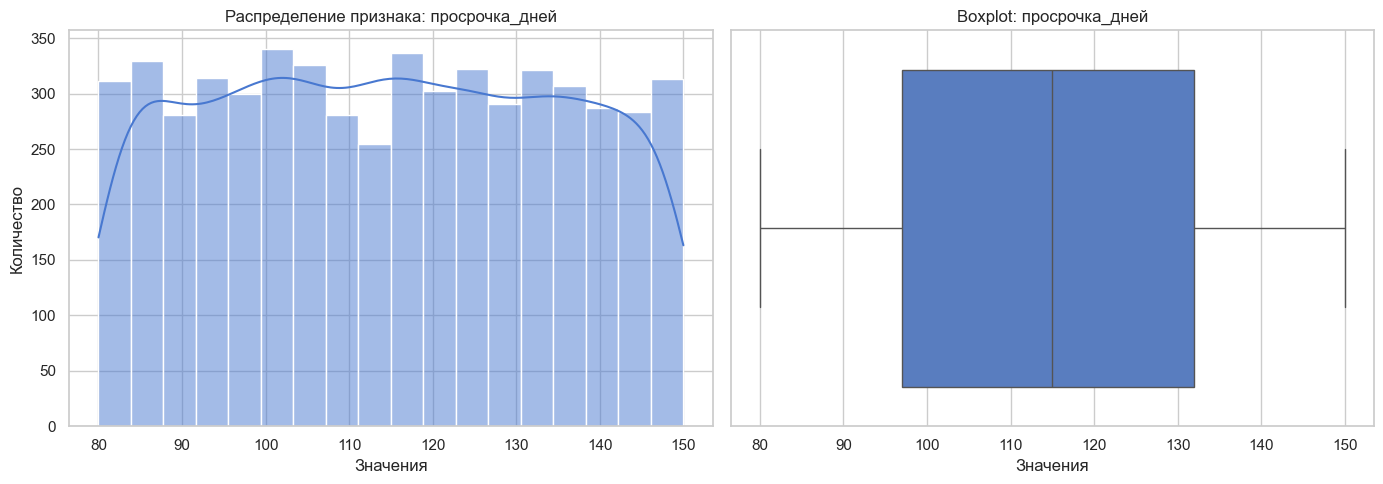

,column,dtype,nunique,missing,missing_share,duplicated_all_table
0,ID,object,13500,0,0.0,0
1,date,object,84,0,0.0,0
2,MCC_5300,float64,423534,0,0.0,0
3,MCC_5814,float64,345459,0,0.0,0
4,MCC_5812,float64,335475,0,0.0,0
5,MCC_5411,float64,462655,0,0.0,0
6,MCC_3990,float64,221493,0,0.0,0
7,MCC_5722,float64,359405,0,0.0,0
8,MCC_4900,float64,353656,0,0.0,0
9,MCC_другое,float64,406485,0,0.0,0


Временные признаки: ['date']
Числовые признаки: ['MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое']
Числовые категориальные признаки: []
Категориальные признаки: []
Временной признак: date
MIN: 2013-01-01 00:00:00
MAX: 2019-12-01 00:00:00
Пропуски: 0


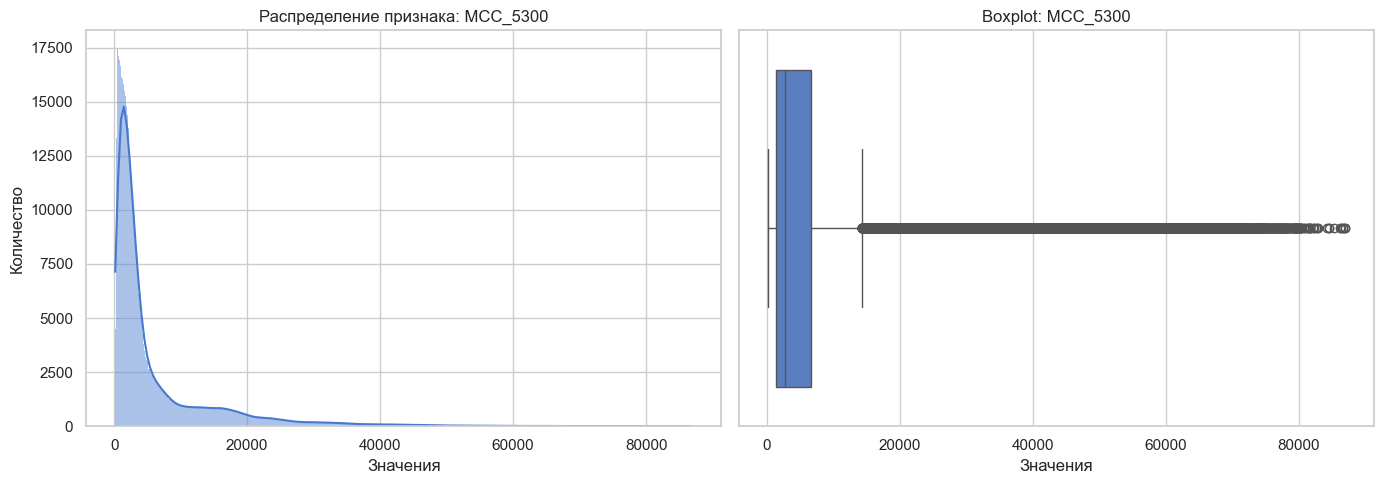

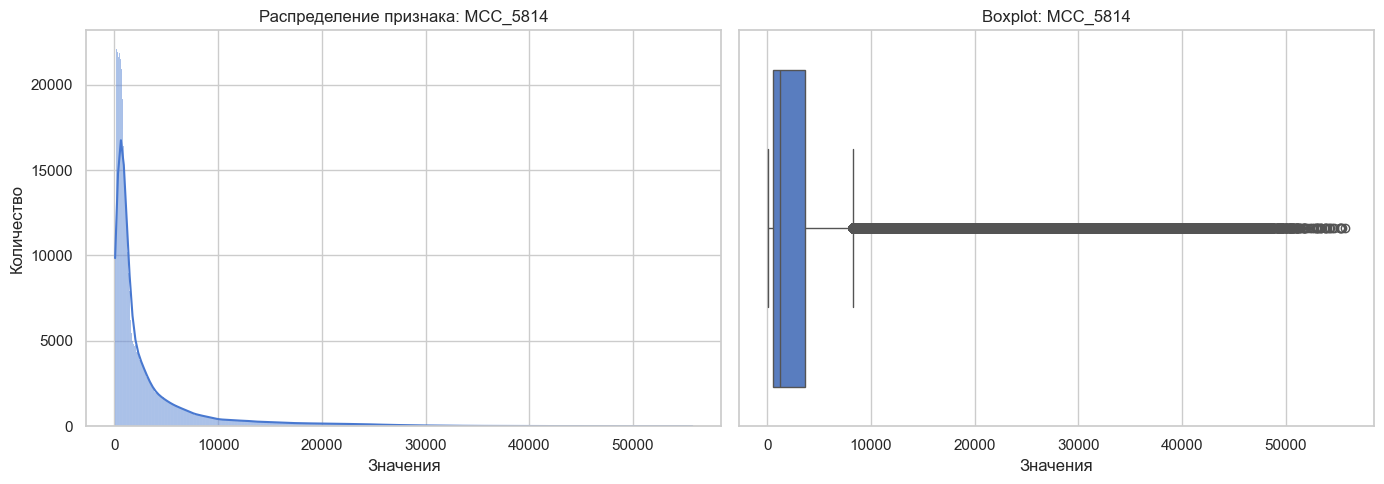

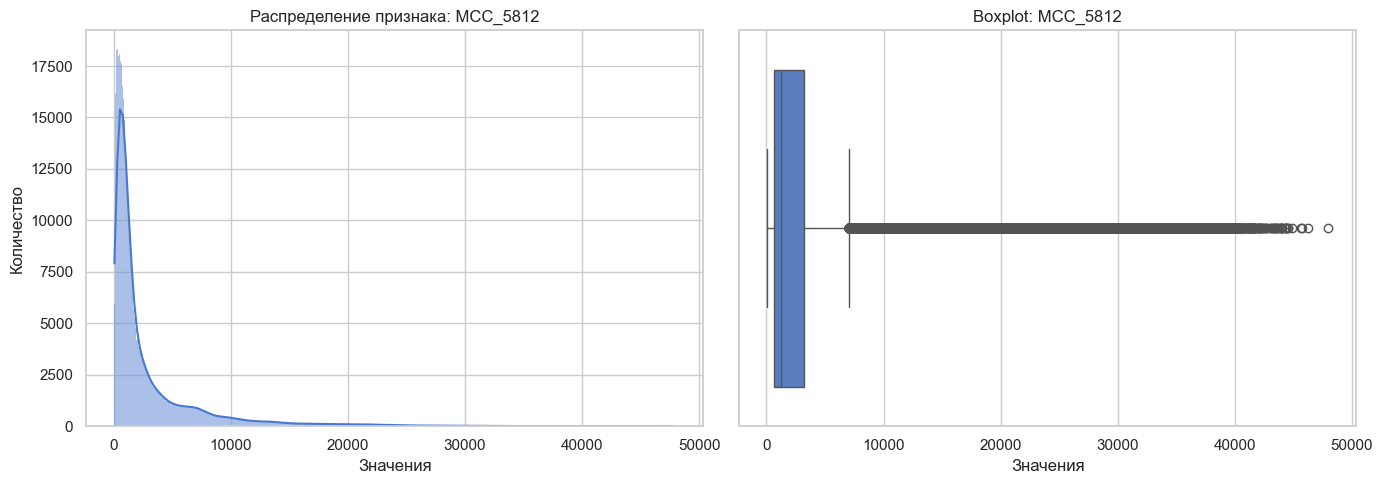

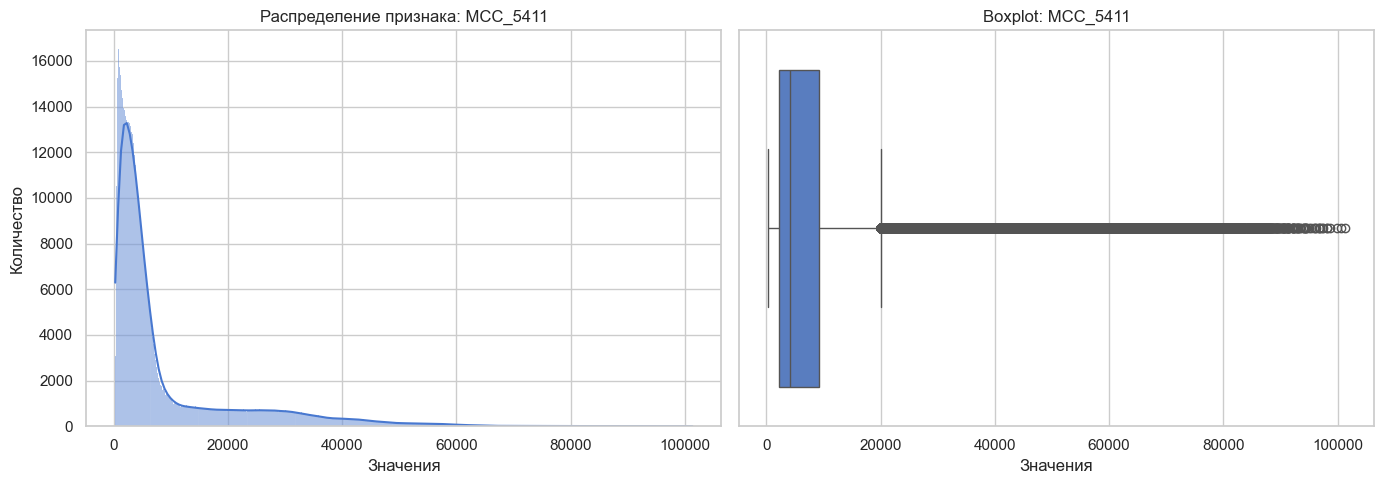

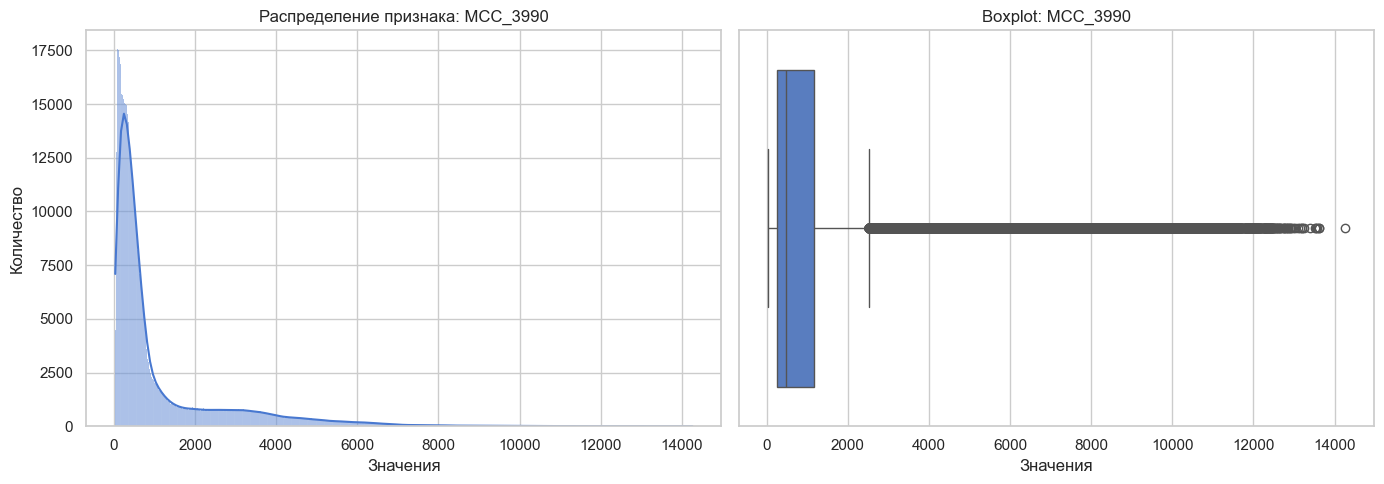

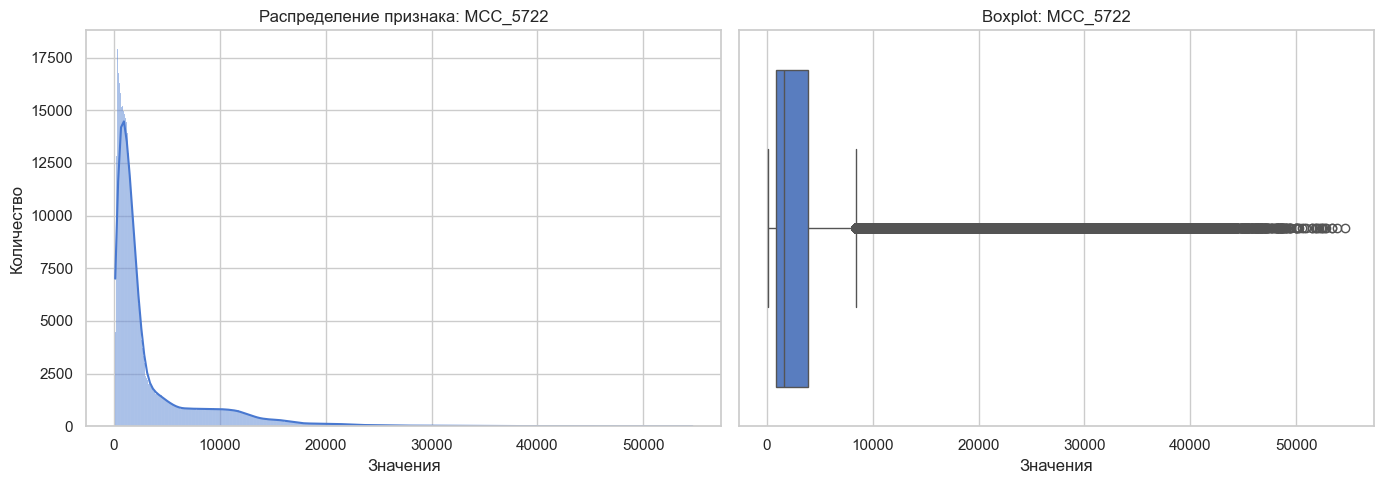

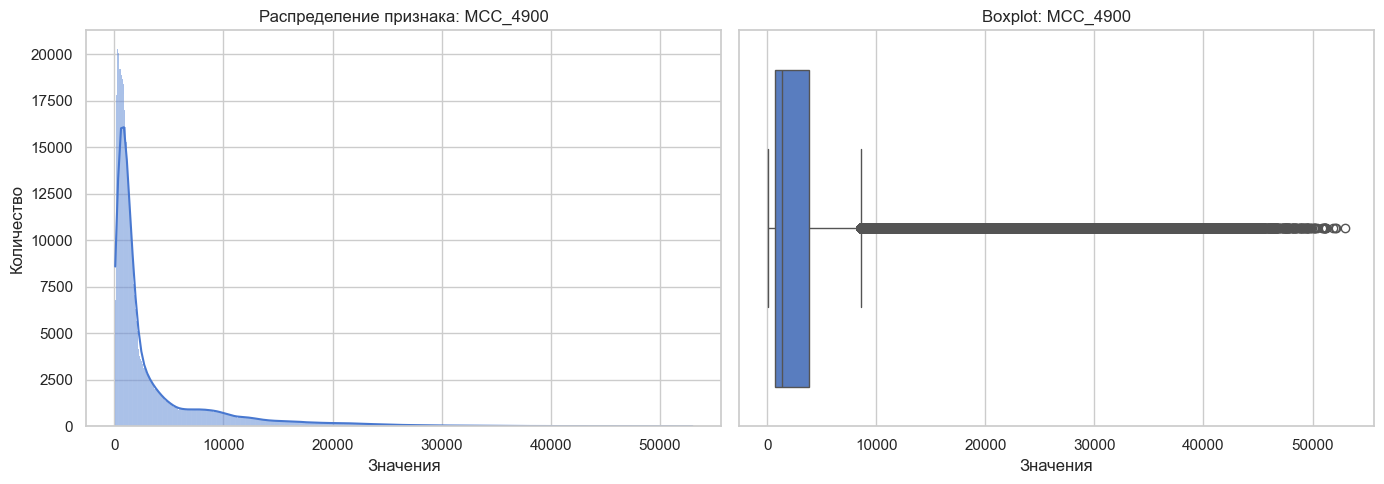

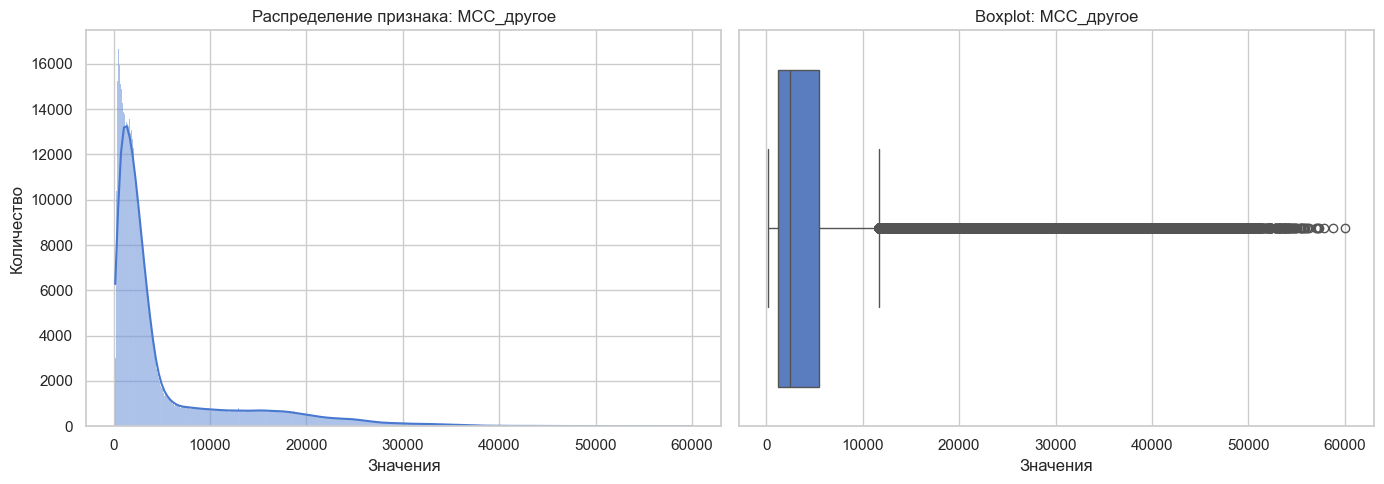

In [6]:
for name, df in list(tables.items())[:2]:
    eda_light(df, columns=df.columns.tolist())

,column,dtype,nunique,missing,missing_share,duplicated_all_table
0,ID,object,13500,0,0.0,0
1,возраст,int64,52,0,0.0,0
2,семейное_положение,object,3,0,0.0,0
3,наличие_иждивенцев,int64,2,0,0.0,0
4,дата_регистрации,object,84,0,0.0,0


Временные признаки: ['дата_регистрации']
Числовые признаки: ['возраст']
Числовые категориальные признаки: ['наличие_иждивенцев']
Категориальные признаки: ['семейное_положение']
Временной признак: дата_регистрации
MIN: 2013-01-01 00:00:00
MAX: 2019-12-01 00:00:00
Пропуски: 0


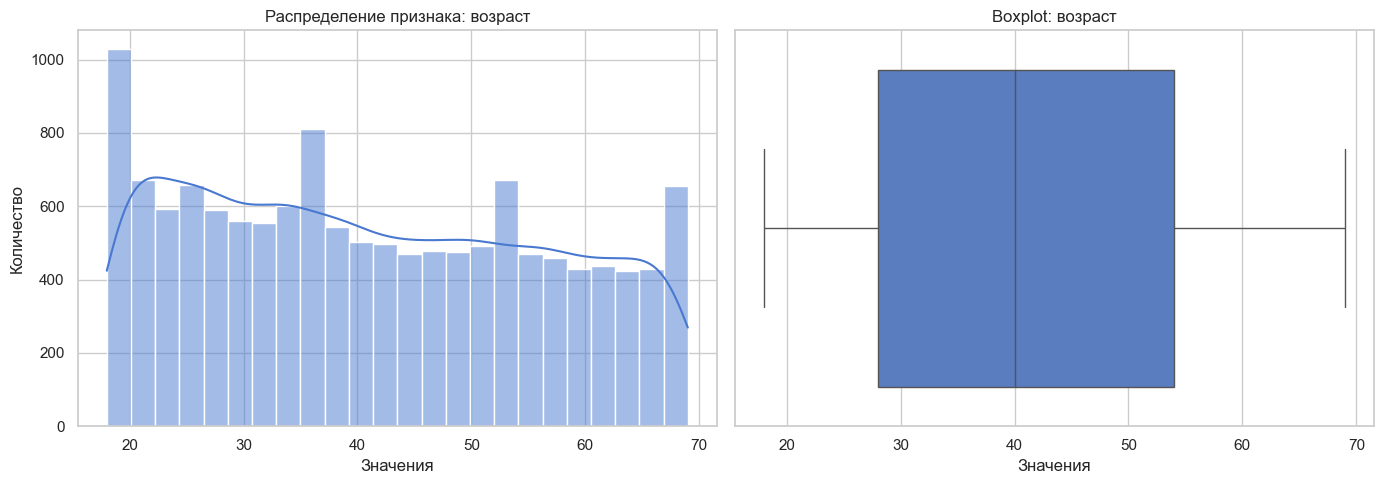

,column,value,counts,dolya
0,наличие_иждивенцев,0,6956,0.515
1,наличие_иждивенцев,1,6544,0.485


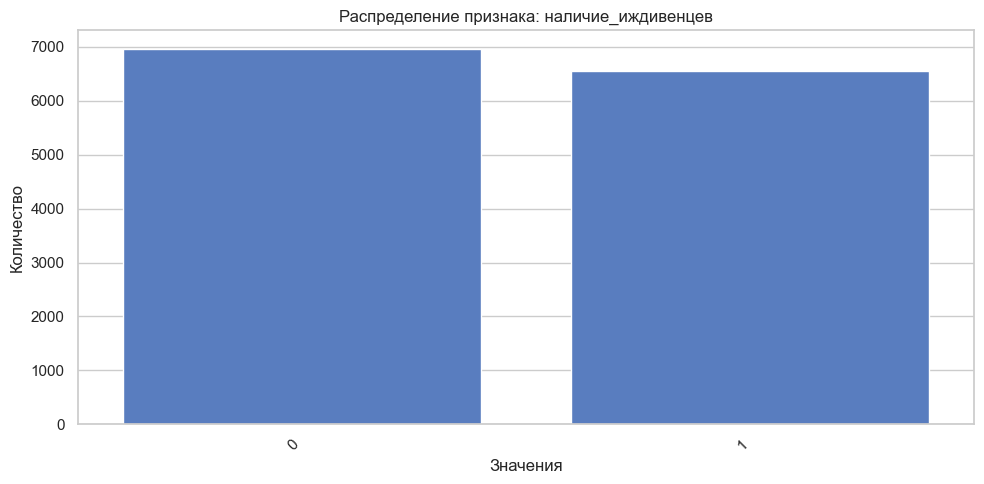

,column,value,counts,dolya
0,семейное_положение,нет семьи,4584,0.340
1,семейное_положение,разведённые,4519,0.335
2,семейное_положение,есть семья,4397,0.326


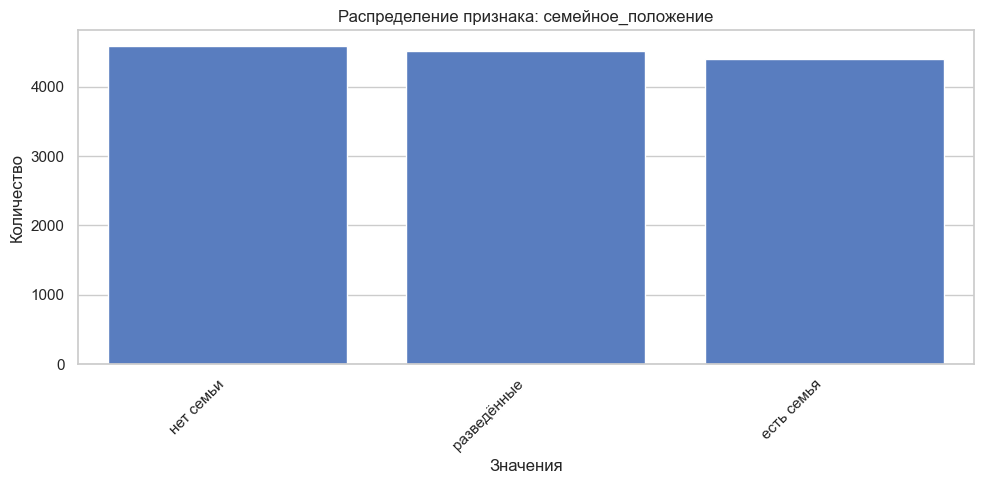

,column,dtype,nunique,missing,missing_share,duplicated_all_table
0,ID,object,13500,0,0.0,0
1,доход,int64,12801,0,0.0,0
2,сумма_кредита,int64,13140,0,0.0,0


Временные признаки: []
Числовые признаки: ['доход', 'сумма_кредита']
Числовые категориальные признаки: []
Категориальные признаки: []


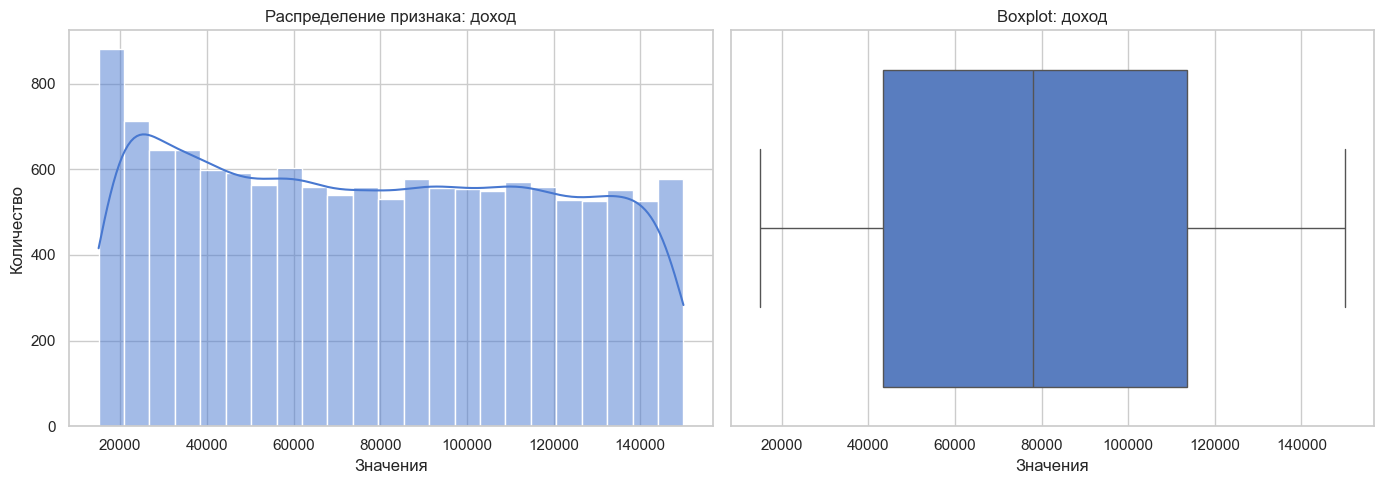

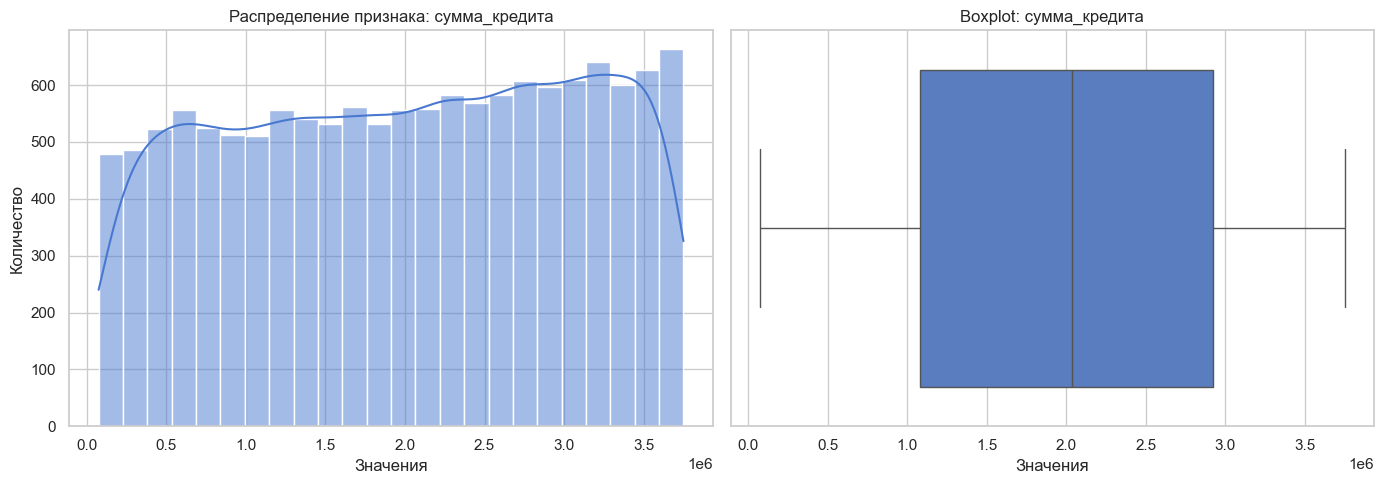

In [7]:
for name, df in list(tables.items())[2:4]:
    eda_light(df, columns=df.columns.tolist())

,column,dtype,nunique,missing,missing_share,duplicated_all_table
0,ID,object,6609,0,0.0,0
1,дата_открытия,object,84,0,0.0,0
2,наличие_ипотеки,int64,1,0,0.0,0


Временные признаки: ['дата_открытия']
Числовые признаки: []
Числовые категориальные признаки: ['наличие_ипотеки']
Категориальные признаки: []
Временной признак: дата_открытия
MIN: 2013-01-01 00:00:00
MAX: 2019-12-01 00:00:00
Пропуски: 0


,column,value,counts,dolya
0,наличие_ипотеки,1,6609,1.0


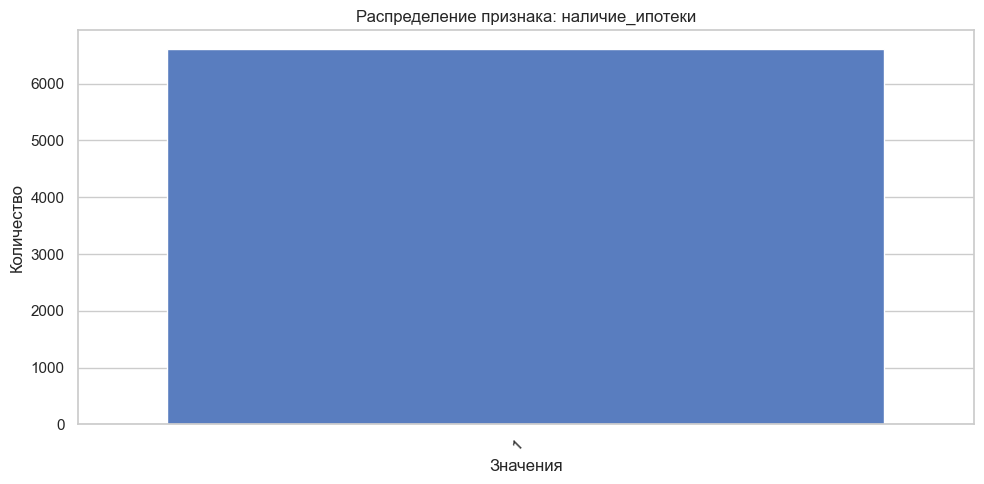

,column,dtype,nunique,missing,missing_share,duplicated_all_table
0,ID,object,13500,0,0.0,0
1,date,object,84,0,0.0,0
2,кредитный_рейтинг,int64,510,0,0.0,0


Временные признаки: ['date']
Числовые признаки: ['кредитный_рейтинг']
Числовые категориальные признаки: []
Категориальные признаки: []
Временной признак: date
MIN: 2013-01-01 00:00:00
MAX: 2019-12-01 00:00:00
Пропуски: 0


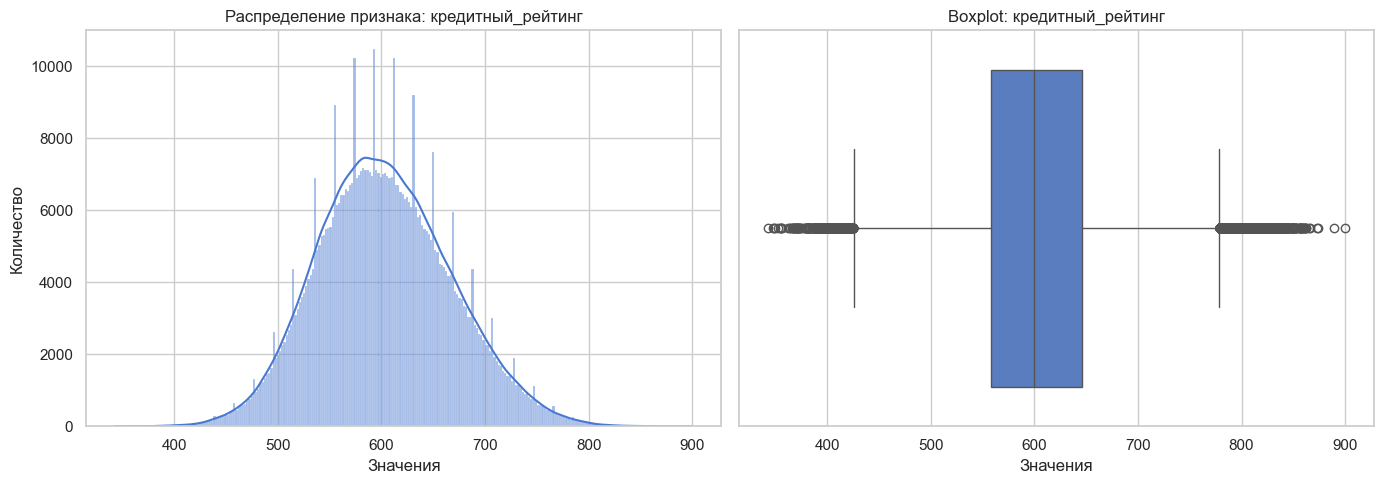

In [8]:
for name, df in list(tables.items())[4:6]:
    eda_light(df, columns=df.columns.tolist())

,column,dtype,nunique,missing,missing_share,duplicated_all_table
0,date,object,84,0,0.0,0
1,учетная_ставка,float64,40,0,0.0,0
2,уровень_безработицы,float64,18,0,0.0,0
3,инфляция,float64,62,0,0.0,0


Временные признаки: ['date']
Числовые признаки: ['учетная_ставка', 'уровень_безработицы', 'инфляция']
Числовые категориальные признаки: []
Категориальные признаки: []
Временной признак: date
MIN: 2013-01-01 00:00:00
MAX: 2019-12-01 00:00:00
Пропуски: 0


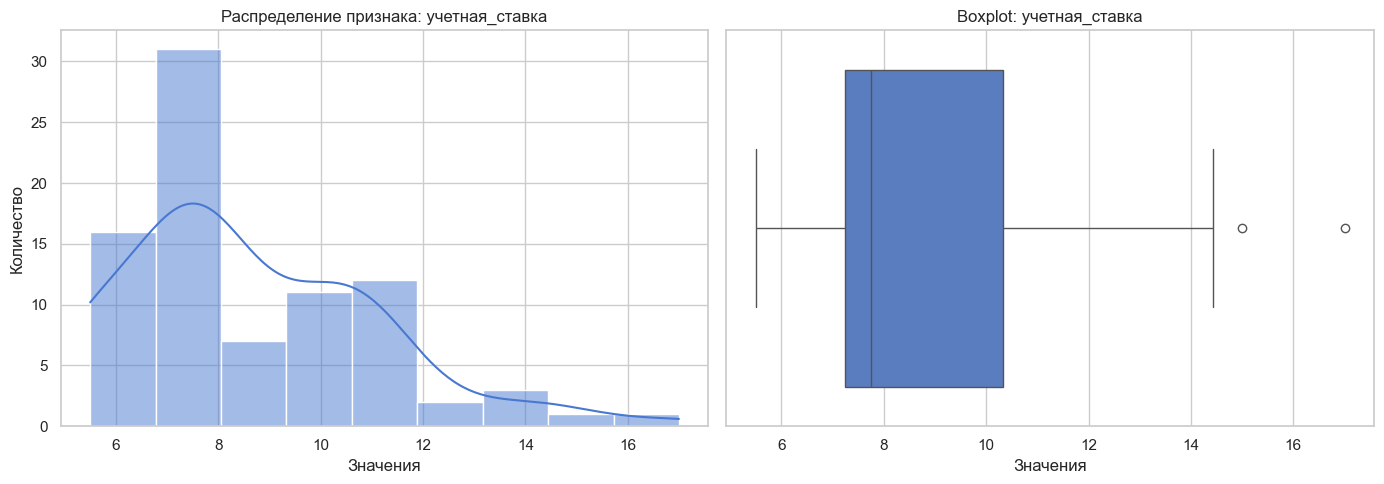

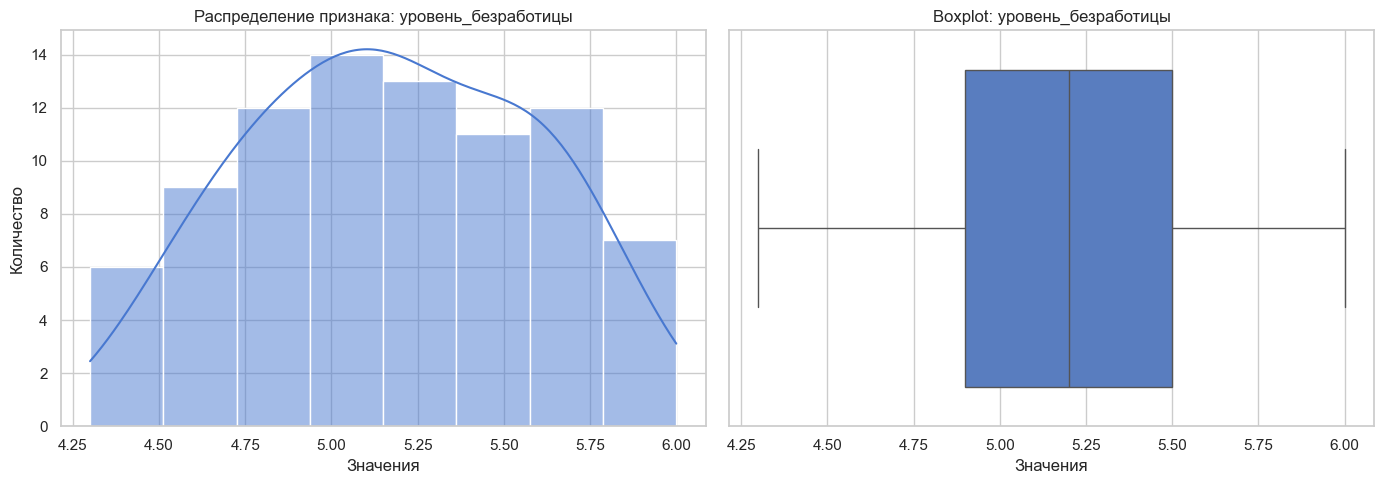

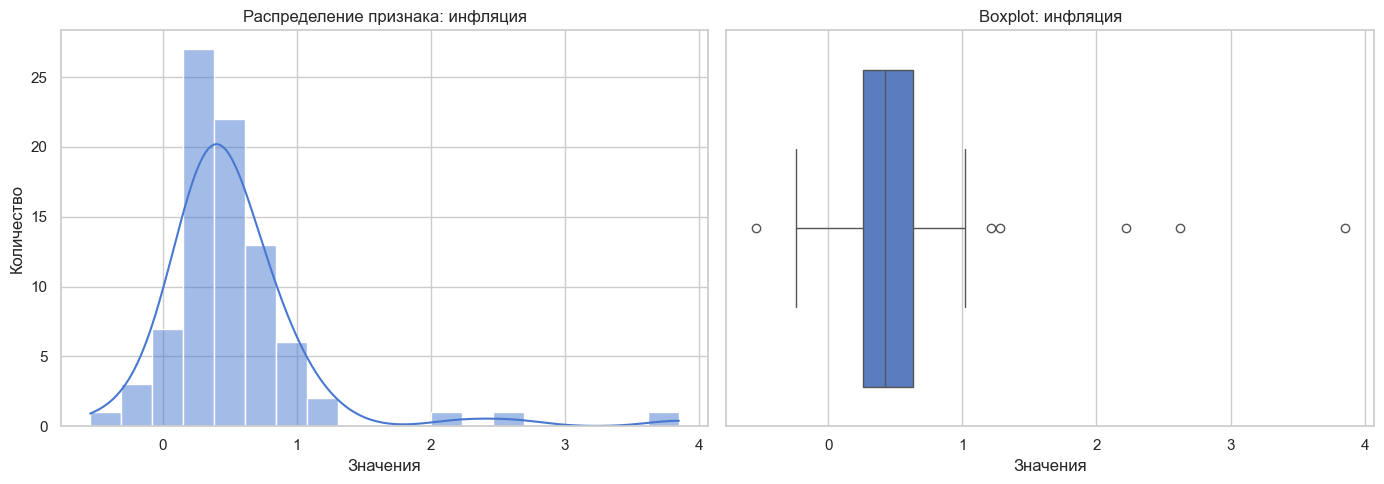

,column,dtype,nunique,missing,missing_share,duplicated_all_table
0,ID,object,13500,0,0.0,0
1,score_date,object,84,0,0.0,0


Временные признаки: ['score_date']
Числовые признаки: []
Числовые категориальные признаки: []
Категориальные признаки: []
Временной признак: score_date
MIN: 2013-01-01 00:00:00
MAX: 2019-12-01 00:00:00
Пропуски: 0


In [9]:
for name, df in list(tables.items())[6:]:
    eda_light(df, columns=df.columns.tolist())

### Краткие выводы по первичному EDA

Первичная проверка показала, что все восемь таблиц загружены корректно. Полных дубликатов строк и пропусков в исходных таблицах не обнаружено. Даты во всех временных таблицах находятся в ожидаемом диапазоне с 2013 по 2019 год, при этом месячная сетка `cohort_grid`, транзакции, кредитный рейтинг и макроэкономические данные покрывают 84 месяца.

Таблицы `transactions`, `credit_rating` и `cohort_grid` имеют одинаковый размер — 577 494 строки, что согласуется с форматом клиент-месяц. В таблицах `client_description` и `credit_description` по 13 500 клиентов, поэтому эти данные можно присоединять по `ID` как статические клиентские признаки. Таблица `mortgage_presence` содержит только клиентов с ипотекой: признак `наличие_ипотеки` принимает только значение 1, поэтому для клиентов без записи после объединения нужно будет явно сформировать отсутствие активной ипотеки (0).

Категориальные признаки выглядят сбалансированно: семейное положение распределено почти равномерно между тремя категориями, а наличие иждивенцев близко к соотношению 50/50.

По числовым признакам видны широкие диапазоны значений и потенциальные выбросы: это ожидаемо для сумм транзакций, дохода, суммы кредита, кредитного рейтинга и длительности просрочки. На следующем этапе нужно проверить ключи объединения (`ID`, `date`, `score_date`) и собрать итоговую таблицу так, чтобы в признаки попадала только информация, доступная на дату скоринга, без утечки данных из будущего.



In [10]:
def check_merge_keys(tables):
    checks = {
        'cohort_grid ID-score_date duplicates': tables['cohort_grid'].duplicated(['ID', 'score_date']).sum(),
        'transactions ID-date duplicates': tables['transactions'].duplicated(['ID', 'date']).sum(),
        'credit_rating ID-date duplicates': tables['credit_rating'].duplicated(['ID', 'date']).sum(),
        'macro_data date duplicates': tables['macro_data'].duplicated(['date']).sum(),
        'client_description ID duplicates': tables['client_description'].duplicated(['ID']).sum(),
        'credit_description ID duplicates': tables['credit_description'].duplicated(['ID']).sum(),
        'mortgage_presence ID duplicates': tables['mortgage_presence'].duplicated(['ID']).sum(),
    }

    for name, value in checks.items():
        print(f'{name}: {value}')

    return checks


def add_future_default_target(data, delays, horizon_days=365):
    rows_before = len(data)
    data = data.copy()
    data['_row_id'] = np.arange(rows_before)

    first_default_events = (
        delays.loc[
            delays['просрочка_дней'] >= 90,
            ['ID', 'дата_начала_периода']
        ]
        .assign(first_default_date=lambda x: pd.to_datetime(x['дата_начала_периода']))
        .sort_values(['ID', 'first_default_date'])
        .groupby('ID', as_index=False)
        .first()[['ID', 'first_default_date']]
    )

    target_frame = data[['_row_id', 'ID', 'score_date']].merge(
        first_default_events,
        on='ID',
        how='left',
        validate='m:1'
    )

    target_frame['window_start'] = target_frame['score_date']
    target_frame['window_end'] = target_frame['score_date'] + pd.Timedelta(days=horizon_days)
    target_frame['default_in_horizon'] = (
        target_frame['first_default_date'].notna()
        & (target_frame['first_default_date'] >= target_frame['window_start'])
        & (target_frame['first_default_date'] < target_frame['window_end'])
    )

    target_by_row = target_frame.set_index('_row_id')['default_in_horizon']
    first_default_by_row = target_frame.set_index('_row_id')['first_default_date']

    data['target'] = data['_row_id'].map(target_by_row).fillna(False).astype(int)
    data['first_default_date'] = data['_row_id'].map(first_default_by_row)

    current_date_defaults = target_frame[
        target_frame['first_default_date'].eq(target_frame['score_date'])
    ]['_row_id'].nunique()

    post_default_observations = target_frame[
        target_frame['first_default_date'].notna()
        & (target_frame['first_default_date'] < target_frame['score_date'])
    ]['_row_id'].nunique()

    print('Наблюдений с первым 90+ дефолтом в дату скоринга:', current_date_defaults)
    print('Наблюдений после первого 90+ дефолта к удалению:', post_default_observations)

    assert len(data) == rows_before, 'Формирование target не должно удалять строки cohort_grid'
    assert data['_row_id'].is_unique, 'Внутренний идентификатор строки должен быть уникальным'

    return data.drop(columns='_row_id')


def build_scoring_dataset(tables, drop_missing_history=True):
    check_merge_keys(tables)

    cohort = tables['cohort_grid'].copy()
    cohort['score_date'] = pd.to_datetime(cohort['score_date'])
    cohort['score_month'] = cohort['score_date'].dt.to_period('M').dt.to_timestamp()

    data = cohort.copy()
    checks = []

    def add_check(step, rows_before, rows_after, added_columns):
        checks.append({
            'step': step,
            'rows_before': rows_before,
            'rows_after': rows_after,
            'rows_changed': rows_after - rows_before,
            'added_columns': added_columns,
            'missing_in_added_columns': data[added_columns].isna().sum().to_dict() if added_columns else {},
        })

    delays = tables['loan_payment_credit'].copy()
    delays['дата_начала_периода'] = pd.to_datetime(delays['дата_начала_периода'])

    rows_before = len(data)
    data = add_future_default_target(data, delays, horizon_days=365)
    add_check('target_first_default_365d_without_row_filtering', rows_before, len(data), ['target', 'first_default_date'])

    rows_before = len(data)
    post_default_mask = (
        data['first_default_date'].notna()
        & (data['first_default_date'] < data['score_date'])
    )
    data = data.loc[~post_default_mask].copy()
    add_check('drop_observations_after_first_default', rows_before, len(data), [])

    assert (
        data['first_default_date'].isna()
        | (data['first_default_date'] >= data['score_date'])
    ).all(), 'После фильтра остались строки после уже произошедшего дефолта'

    client_description = tables['client_description'].copy()
    client_description['дата_регистрации'] = pd.to_datetime(client_description['дата_регистрации'])

    rows_before = len(data)
    data = data.merge(client_description, on='ID', how='left', validate='m:1')
    add_check(
        'client_description',
        rows_before,
        len(data),
        ['возраст', 'семейное_положение', 'наличие_иждивенцев', 'дата_регистрации']
    )

    data['client_age_months'] = (
        (data['score_date'].dt.year - data['дата_регистрации'].dt.year) * 12
        + (data['score_date'].dt.month - data['дата_регистрации'].dt.month)
    )

    credit_description = tables['credit_description'].copy()

    rows_before = len(data)
    data = data.merge(credit_description, on='ID', how='left', validate='m:1')
    add_check('credit_description', rows_before, len(data), ['доход', 'сумма_кредита'])

    mortgage = tables['mortgage_presence'].copy()
    mortgage['дата_открытия'] = pd.to_datetime(mortgage['дата_открытия'])

    mortgage_first = (
        mortgage.loc[mortgage['наличие_ипотеки'] == 1, ['ID', 'дата_открытия']]
        .sort_values(['ID', 'дата_открытия'])
        .groupby('ID', as_index=False)
        .first()
        .rename(columns={'дата_открытия': 'mortgage_open_date'})
    )

    rows_before = len(data)

    data = data.merge(mortgage_first, on='ID', how='left', validate='m:1')

    data['mortgage_active'] = (
        data['mortgage_open_date'].notna()
        & (data['mortgage_open_date'] <= data['score_date'])
    ).astype(int)

    data = data.drop(columns='mortgage_open_date')

    add_check('mortgage_presence', rows_before, len(data), ['mortgage_active'])

    data['feature_month'] = data['score_month'] - pd.DateOffset(months=1)

    transactions = tables['transactions'].copy()
    transactions['date'] = pd.to_datetime(transactions['date'])
    transaction_columns = [column for column in transactions.columns if column.startswith('MCC_')]

    rows_before = len(data)

    data = data.merge(
        transactions[['ID', 'date'] + transaction_columns],
        left_on=['ID', 'feature_month'],
        right_on=['ID', 'date'],
        how='left',
        validate='m:1'
    )

    data = data.drop(columns='date')

    add_check('transactions_previous_month', rows_before, len(data), transaction_columns)

    credit_rating = tables['credit_rating'].copy()
    credit_rating['date'] = pd.to_datetime(credit_rating['date'])

    rows_before = len(data)

    data = data.merge(
        credit_rating[['ID', 'date', 'кредитный_рейтинг']],
        left_on=['ID', 'feature_month'],
        right_on=['ID', 'date'],
        how='left',
        validate='m:1'
    )

    data = data.drop(columns='date')

    add_check('credit_rating_previous_month', rows_before, len(data), ['кредитный_рейтинг'])

    macro_data = tables['macro_data'].copy()
    macro_data['date'] = pd.to_datetime(macro_data['date'])
    macro_columns = ['учетная_ставка', 'уровень_безработицы', 'инфляция']

    rows_before = len(data)

    data = data.merge(
        macro_data[['date'] + macro_columns],
        left_on='feature_month',
        right_on='date',
        how='left',
        validate='m:1'
    )

    data = data.drop(columns='date')

    add_check('macro_previous_month', rows_before, len(data), macro_columns)

    history_columns = transaction_columns + ['кредитный_рейтинг'] + macro_columns

    if drop_missing_history:
        rows_before = len(data)

        data = data.dropna(subset=history_columns).copy()

        add_check('drop_missing_previous_month_history', rows_before, len(data), [])

    data = data.drop(columns=[
        'score_month',
        'feature_month',
        'дата_регистрации',
        'first_default_date',
    ])

    checks_df = pd.DataFrame(checks)

    display(checks_df)

    print('Итоговый размер:', data.shape)
    print('Распределение target:')
    display(data['target'].value_counts(normalize=True).rename('share').to_frame())

    merge_steps = checks_df[
        ~checks_df['step'].isin([
            'target_first_default_365d_without_row_filtering',
            'drop_observations_after_first_default',
            'drop_missing_previous_month_history'
        ])
    ]

    assert merge_steps['rows_changed'].eq(0).all(), 'После одного из merge изменилось количество строк'
    assert data.duplicated(['ID', 'score_date']).sum() == 0, 'После merge появились дубликаты ID-score_date'

    return data, checks_df


In [11]:
df, merge_checks = build_scoring_dataset(tables)

cohort_grid ID-score_date duplicates: 0
transactions ID-date duplicates: 0
credit_rating ID-date duplicates: 0
macro_data date duplicates: 0
client_description ID duplicates: 0
credit_description ID duplicates: 0
mortgage_presence ID duplicates: 0
Наблюдений с первым 90+ дефолтом в дату скоринга: 4712
Наблюдений после первого 90+ дефолта к удалению: 139115


,step,rows_before,rows_after,rows_changed,added_columns,missing_in_added_columns
0,target_first_default_365d_without_row_filtering,577494,577494,0,"[target, first_default_date]","{'target': 0, 'first_default_date': 376206}"
1,drop_observations_after_first_default,577494,438379,-139115,[],{}
2,client_description,438379,438379,0,"[возраст, семейное_положение, наличие_иждивенц...","{'возраст': 0, 'семейное_положение': 0, 'налич..."
3,credit_description,438379,438379,0,"[доход, сумма_кредита]","{'доход': 0, 'сумма_кредита': 0}"
4,mortgage_presence,438379,438379,0,[mortgage_active],{'mortgage_active': 0}
5,transactions_previous_month,438379,438379,0,"[MCC_5300, MCC_5814, MCC_5812, MCC_5411, MCC_3...","{'MCC_5300': 13500, 'MCC_5814': 13500, 'MCC_58..."
6,credit_rating_previous_month,438379,438379,0,[кредитный_рейтинг],{'кредитный_рейтинг': 13500}
7,macro_previous_month,438379,438379,0,"[учетная_ставка, уровень_безработицы, инфляция]","{'учетная_ставка': 152, 'уровень_безработицы':..."
8,drop_missing_previous_month_history,438379,424879,-13500,[],{}


Итоговый размер: (424879, 22)
Распределение target:


,share
target,
0,0.888639
1,0.111361


In [12]:
def show_target_sanity_check(data, delays, sample_size=5, horizon_days=365):
    first_default_events = (
        delays.loc[delays['просрочка_дней'] >= 90, ['ID', 'дата_начала_периода']]
        .assign(first_default_date=lambda x: pd.to_datetime(x['дата_начала_периода']))
        .sort_values(['ID', 'first_default_date'])
        .groupby('ID', as_index=False)
        .first()[['ID', 'first_default_date']]
    )

    examples = []
    positive_rows = data[data['target'] == 1].head(sample_size)
    negative_rows = data[data['target'] == 0].head(sample_size)

    for _, row in pd.concat([positive_rows, negative_rows]).iterrows():
        score_date = row['score_date']
        window_start = score_date
        window_end = score_date + pd.Timedelta(days=horizon_days)
        first_default_date = first_default_events.loc[
            first_default_events['ID'] == row['ID'],
            'first_default_date'
        ]
        first_default_date = first_default_date.iloc[0] if len(first_default_date) else pd.NaT
        default_in_target_window = (
            pd.notna(first_default_date)
            and window_start <= first_default_date < window_end
        )

        examples.append({
            'ID': row['ID'],
            'score_date': score_date,
            'window_start': window_start,
            'window_end_exclusive': window_end,
            'first_90plus_default_date': first_default_date,
            'target': row['target'],
            'manual_target': int(default_in_target_window),
        })

    sanity_df = pd.DataFrame(examples)
    display(sanity_df)
    assert (sanity_df['target'] == sanity_df['manual_target']).all(), 'Sanity-check target выявил ошибку в окне [score_date, score_date + 365 дней)'


show_target_sanity_check(df, tables['loan_payment_credit'])


,ID,score_date,window_start,window_end_exclusive,first_90plus_default_date,target,manual_target
0,IDF55109846,2014-01-01,2014-01-01,2015-01-01,2014-12-01,1,1
1,IDF55109846,2014-02-01,2014-02-01,2015-02-01,2014-12-01,1,1
2,IDF55109846,2014-03-01,2014-03-01,2015-03-01,2014-12-01,1,1
3,IDF55109846,2014-04-01,2014-04-01,2015-04-01,2014-12-01,1,1
4,IDF55109846,2014-05-01,2014-05-01,2015-05-01,2014-12-01,1,1
5,IDF55109846,2013-06-01,2013-06-01,2014-06-01,2014-12-01,0,0
6,IDF55109846,2013-07-01,2013-07-01,2014-07-01,2014-12-01,0,0
7,IDF55109846,2013-08-01,2013-08-01,2014-08-01,2014-12-01,0,0
8,IDF55109846,2013-09-01,2013-09-01,2014-09-01,2014-12-01,0,0
9,IDF55109846,2013-10-01,2013-10-01,2014-10-01,2014-12-01,0,0


Перед объединением были проверены ключи таблиц: дубликатов по `ID + score_date`, `ID + date`, `date` и `ID` не обнаружено. Это значит, что при присоединении данных не должно возникать размножения строк из-за неуникальных ключей.

Итоговая таблица собрана на уровне клиент-месяц на базе `cohort_grid`. Целевая переменная формируется отдельно для каждой строки наблюдения: берётся первый по времени эпизод клиента с `просрочка_дней >= 90` и проверяется, попадает ли его `дата_начала_периода` в интервал `[score_date, score_date + 365 дней)`. Если попадает, `target = 1`, иначе `target = 0`.

После расчёта target удаляются строки, где первый 90+ дефолт уже произошёл до даты скоринга (`дата_начала_периода < score_date`). Это сохраняет временную постановку задачи: модель обучается на наблюдениях до первого дефолтного эпизода, а не на строках, где дефолт уже случился в прошлом.

Признаки транзакций, кредитного рейтинга и макроэкономики присоединены за предыдущий месяц относительно даты скоринга. Такой подход сохраняет временную структуру задачи и снижает риск утечки данных из будущего. Пропуски в признаках предыдущего месяца связаны с первыми месяцами наблюдения клиентов и отсутствием макроэкономических данных за период до начала исходной таблицы.


In [13]:
df = df.sort_values(['ID', 'score_date']).copy()

mcc_columns = [
    'MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411',
    'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое'
]
rolling_windows = [3, 6, 12]


# Базовые финансовые и транзакционные признаки.
df['credit_to_income'] = df['сумма_кредита'] / df['доход']
df['total_mcc_spending'] = df[mcc_columns].sum(axis=1)
df['no_spending_month'] = (df['total_mcc_spending'] == 0).astype(int)

for column in mcc_columns:
    df[f'{column.lower()}_share'] = np.where(
        df['total_mcc_spending'] > 0,
        df[column] / df['total_mcc_spending'],
        0
    )

client_groups = df.groupby('ID', group_keys=False)

# Лаги: в текущей строке уже лежит предыдущий месяц относительно score_date,
# поэтому shift(1) даёт ещё более ранний месяц.
df['credit_rating_lag_2m'] = client_groups['кредитный_рейтинг'].shift(1)
df['total_spending_lag_2m'] = client_groups['total_mcc_spending'].shift(1)
df['credit_rating_delta_1m'] = df['кредитный_рейтинг'] - df['credit_rating_lag_2m']
df['total_spending_delta_1m'] = df['total_mcc_spending'] - df['total_spending_lag_2m']

# Rolling-признаки по общему поведению клиента.
for window in rolling_windows:
    spending_roll_sum = client_groups['total_mcc_spending'].transform(
        lambda s, window=window: s.rolling(window=window, min_periods=1).sum()
    )

    df[f'total_spending_roll_{window}m_mean'] = client_groups['total_mcc_spending'].transform(
        lambda s, window=window: s.rolling(window=window, min_periods=1).mean()
    )
    df[f'total_spending_roll_{window}m_std'] = client_groups['total_mcc_spending'].transform(
        lambda s, window=window: s.rolling(window=window, min_periods=2).std()
    ).fillna(0)
    df[f'no_spending_roll_{window}m_count'] = client_groups['no_spending_month'].transform(
        lambda s, window=window: s.rolling(window=window, min_periods=1).sum()
    )
    df[f'credit_rating_roll_{window}m_mean'] = client_groups['кредитный_рейтинг'].transform(
        lambda s, window=window: s.rolling(window=window, min_periods=1).mean()
    )
    df[f'credit_rating_roll_{window}m_std'] = client_groups['кредитный_рейтинг'].transform(
        lambda s, window=window: s.rolling(window=window, min_periods=2).std()
    ).fillna(0)
    df[f'credit_rating_delta_{window}m'] = (
        df['кредитный_рейтинг']
        - client_groups['кредитный_рейтинг'].shift(window - 1)
    )

    # Доли MCC внутри rolling-окна показывают изменение структуры расходов, а не только их объём.
    for column in mcc_columns:
        mcc_roll_sum = client_groups[column].transform(
            lambda s, window=window: s.rolling(window=window, min_periods=1).sum()
        )
        df[f'{column.lower()}_roll_{window}m_share'] = np.where(
            spending_roll_sum > 0,
            mcc_roll_sum / spending_roll_sum,
            0
        )

feature_columns_created = [
    column for column in df.columns
    if 'roll_' in column or column.endswith('_delta_1m') or column.endswith('_share')
]

# NaN появляются только там, где для первого месяца клиента ещё нет лага или окна
# с двумя наблюдениями. Заполняем их явно, чтобы не прятать это в пайплайне.
df[feature_columns_created] = df[feature_columns_created].fillna(0)

assert (df['client_age_months'] >= 0).all(), 'Есть наблюдения с датой регистрации позже даты скоринга'
assert np.isfinite(df['credit_to_income']).all(), 'credit_to_income содержит бесконечные значения'
assert df[feature_columns_created].isna().sum().sum() == 0, 'В созданных динамических признаках остались NaN'
assert df.duplicated(['ID', 'score_date']).sum() == 0, 'После feature engineering появились дубликаты ID-score_date'

lag_check = (
    df.sort_values(['ID', 'score_date'])
    .assign(previous_score_date=lambda x: x.groupby('ID')['score_date'].shift(1))
)
lag_check = lag_check[lag_check['previous_score_date'].notna()].copy()
lag_check['month_gap'] = (
    (lag_check['score_date'].dt.year - lag_check['previous_score_date'].dt.year) * 12
    + (lag_check['score_date'].dt.month - lag_check['previous_score_date'].dt.month)
)
print('Максимальный разрыв между соседними строками клиента после подготовки:', lag_check['month_gap'].max())

sample_client_id = df['ID'].value_counts()[lambda x: x >= 12].index[0]
sample_client = df[df['ID'] == sample_client_id].sort_values('score_date').copy()
sample_row = sample_client.iloc[5]
sample_history = sample_client[sample_client['score_date'] <= sample_row['score_date']].tail(3)

assert sample_history['score_date'].max() == sample_row['score_date'], 'Rolling-окно должно заканчиваться текущей строкой наблюдения'
assert np.isclose(
    sample_row['total_spending_roll_3m_mean'],
    sample_history['total_mcc_spending'].mean()
), 'Rolling-признак расходов за 3 месяца рассчитан не по прошлой истории клиента'
sample_spending_sum = sample_history['total_mcc_spending'].sum()
expected_mcc_share = (
    sample_history['MCC_5411'].sum() / sample_spending_sum
    if sample_spending_sum > 0
    else 0
)
assert np.isclose(
    sample_row['mcc_5411_roll_3m_share'],
    expected_mcc_share
), 'Rolling-доля MCC рассчитана не по прошлой истории клиента'

print('Количество созданных rolling/delta/share признаков:', len(feature_columns_created))


Максимальный разрыв между соседними строками клиента после подготовки: 1
Количество созданных rolling/delta/share признаков: 49


Были созданы дополнительные признаки, описывающие долговую нагрузку, структуру расходов и динамику клиента во времени. Признак `credit_to_income` показывает отношение суммы кредита к месячному доходу, `total_mcc_spending` отражает общий объём трат по MCC-категориям, а долевые признаки MCC показывают структуру расходов за последний доступный месяц.

Для динамики добавлены лаги и rolling-признаки за 3, 6 и 12 месяцев: средний уровень расходов, волатильность расходов, количество месяцев без транзакционной активности, средний кредитный рейтинг, изменение рейтинга и доли MCC-категорий внутри rolling-окна. Эти признаки важны именно для поведенческого скоринга: модель видит не только один месяц, но и изменение структуры поведения клиента. Дополнительная проверка в коде вручную сверяет rolling-окно на одном клиенте и подтверждает, что оно не обращается к будущим месяцам.


In [14]:
df = df.sort_values('score_date').copy()

last_date = df['score_date'].max()
horizon_gap = pd.DateOffset(months=12)


test_start = last_date - pd.DateOffset(months=11)
calib_end = test_start - horizon_gap
calib_start = calib_end - pd.DateOffset(months=12)
train_end = calib_start - horizon_gap

train_df = df[df['score_date'] < train_end].copy()
calib_df = df[
    (df['score_date'] >= calib_start)
    & (df['score_date'] < calib_end)
].copy()
test_df = df[df['score_date'] >= test_start].copy()

print('train:', train_df['score_date'].min(), train_df['score_date'].max(), train_df.shape)
print('calib:', calib_df['score_date'].min(), calib_df['score_date'].max(), calib_df.shape)
print('test:', test_df['score_date'].min(), test_df['score_date'].max(), test_df.shape)
print('gap train-calib:', train_end, '...', calib_start - pd.DateOffset(months=1))
print('gap calib-test:', calib_end, '...', test_start - pd.DateOffset(months=1))

assert train_df['score_date'].max() + horizon_gap < calib_df['score_date'].min(), 'Train target window overlaps calibration observations'
assert calib_df['score_date'].max() + horizon_gap < test_df['score_date'].min(), 'Calibration target window overlaps test observations'


train: 2013-02-01 00:00:00 2015-12-01 00:00:00 (90265, 79)
calib: 2017-01-01 00:00:00 2017-12-01 00:00:00 (77551, 79)
test: 2019-01-01 00:00:00 2019-12-01 00:00:00 (101796, 79)
gap train-calib: 2016-01-01 00:00:00 ... 2016-12-01 00:00:00
gap calib-test: 2018-01-01 00:00:00 ... 2018-12-01 00:00:00


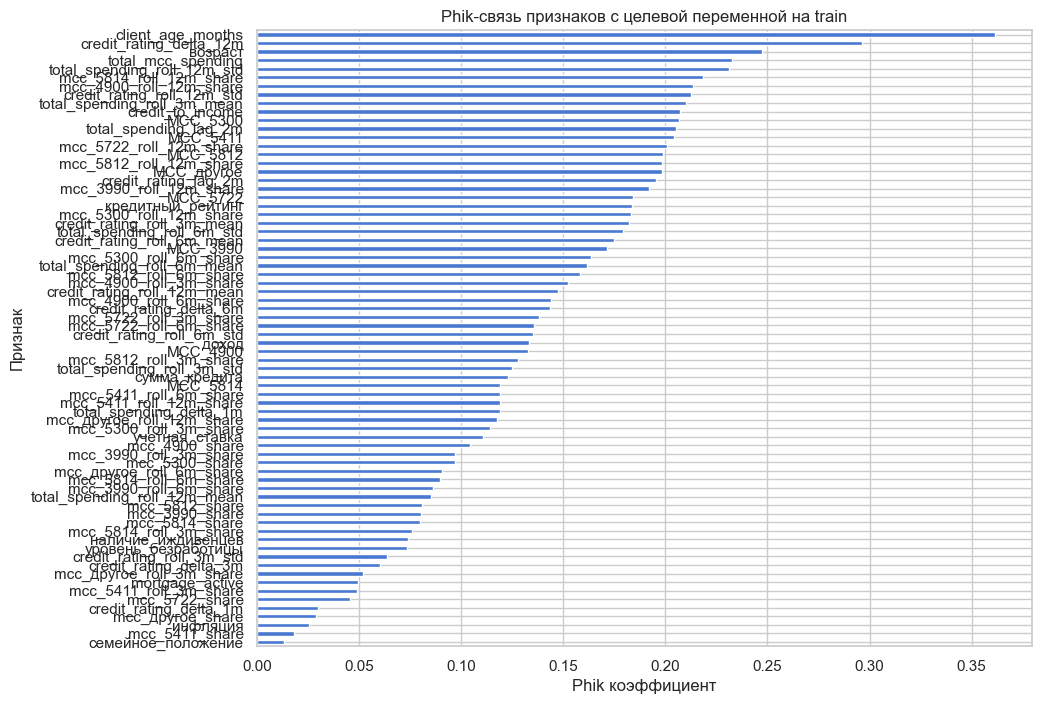

client_age_months              0.361379
credit_rating_delta_12m        0.296049
возраст                        0.247303
total_mcc_spending             0.232697
total_spending_roll_12m_std    0.231006
                                 ...   
credit_rating_delta_1m         0.029871
mcc_другое_share               0.028854
инфляция                       0.025731
mcc_5411_share                 0.018200
семейное_положение             0.013181
Name: target, Length: 72, dtype: float64

In [15]:
phik_df = train_df.drop(columns=['ID', 'score_date'])

interval_cols = phik_df.select_dtypes(include='number').columns.drop('target')

phik_corr = phik_df.phik_matrix(interval_cols=interval_cols)

target_phik = (
    phik_corr['target']
    .drop('target', errors='ignore')
    .sort_values(ascending=False)
)

target_phik.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Phik-связь признаков с целевой переменной на train')
plt.xlabel('Phik коэффициент')
plt.ylabel('Признак')
plt.show()

display(target_phik)


По PhiK на обучающей выборке наиболее заметную связь с целевой переменной показывают признаки клиентского стажа, общего объёма расходов, лагового объёма расходов, отдельных MCC-категорий и кредитного рейтинга.

Наиболее слабую связь с таргетом показали `семейное_положение`, `mcc_5722_share`, `mortgage_active` и `наличие_иждивенцев`. При этом полностью исключать их на данном этапе не нужно: ансамблевая модель может использовать слабые признаки в комбинации с другими переменными.

PhiK считается только на обучающей части после временного разделения, поэтому этот анализ не использует calibration/test для отбора признаков.


In [16]:
groups = train_df['score_date'].dt.to_period('M')

cv = GroupTimeSeriesSplit(
    n_splits=3,
    test_size=6,
    gap_size=12,
    window_type='expanding'
)


In [17]:
for fold, (train_idx, valid_idx) in enumerate(cv.split(train_df, groups=groups)):
    fold_train = train_df.iloc[train_idx]
    fold_valid = train_df.iloc[valid_idx]

    print(
        fold,
        fold_train['score_date'].min(),
        fold_train['score_date'].max(),
        fold_valid['score_date'].min(),
        fold_valid['score_date'].max(),
    )

    assert fold_train['score_date'].max() + horizon_gap < fold_valid['score_date'].min(), 'CV fold target window overlaps validation observations'


0 2013-02-01 00:00:00 2014-04-01 00:00:00 2015-05-01 00:00:00 2015-10-01 00:00:00
1 2013-02-01 00:00:00 2014-05-01 00:00:00 2015-06-01 00:00:00 2015-11-01 00:00:00
2 2013-02-01 00:00:00 2014-06-01 00:00:00 2015-07-01 00:00:00 2015-12-01 00:00:00


In [18]:
target_column = 'target'

service_columns = [
    'ID',
    'score_date',
]

drop_columns = service_columns + [target_column]

X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target_column]

X_calib = calib_df.drop(columns=drop_columns)
y_calib = calib_df[target_column]

X_test = test_df.drop(columns=drop_columns)
y_test = test_df[target_column]

print(
    'train:', X_train.shape, y_train.shape[0],
    'calib:', X_calib.shape, y_calib.shape[0],
    'test:', X_test.shape, y_test.shape[0]
)

train: (90265, 76) 90265 calib: (77551, 76) 77551 test: (101796, 76) 101796


In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90265 entries, 318569 to 234028
Data columns (total 76 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   возраст                       90265 non-null  int64  
 1   семейное_положение            90265 non-null  object 
 2   наличие_иждивенцев            90265 non-null  int64  
 3   client_age_months             90265 non-null  int32  
 4   доход                         90265 non-null  int64  
 5   сумма_кредита                 90265 non-null  int64  
 6   mortgage_active               90265 non-null  int64  
 7   MCC_5300                      90265 non-null  float64
 8   MCC_5814                      90265 non-null  float64
 9   MCC_5812                      90265 non-null  float64
 10  MCC_5411                      90265 non-null  float64
 11  MCC_3990                      90265 non-null  float64
 12  MCC_5722                      90265 non-null  float64
 13  

In [20]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

print('cat_cols:', cat_cols)
print('num_cols:', num_cols)

cat_cols: ['семейное_положение']
num_cols: ['возраст', 'наличие_иждивенцев', 'client_age_months', 'доход', 'сумма_кредита', 'mortgage_active', 'MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое', 'кредитный_рейтинг', 'учетная_ставка', 'уровень_безработицы', 'инфляция', 'credit_to_income', 'total_mcc_spending', 'no_spending_month', 'mcc_5300_share', 'mcc_5814_share', 'mcc_5812_share', 'mcc_5411_share', 'mcc_3990_share', 'mcc_5722_share', 'mcc_4900_share', 'mcc_другое_share', 'credit_rating_lag_2m', 'total_spending_lag_2m', 'credit_rating_delta_1m', 'total_spending_delta_1m', 'total_spending_roll_3m_mean', 'total_spending_roll_3m_std', 'no_spending_roll_3m_count', 'credit_rating_roll_3m_mean', 'credit_rating_roll_3m_std', 'credit_rating_delta_3m', 'mcc_5300_roll_3m_share', 'mcc_5814_roll_3m_share', 'mcc_5812_roll_3m_share', 'mcc_5411_roll_3m_share', 'mcc_3990_roll_3m_share', 'mcc_5722_roll_3m_share', 'mcc_4900_roll_3m_share', 'mcc_другое_roll_

In [21]:
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler()),
])

num_forest = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])

cat_pipe = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor_logistic = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
    ],
    remainder='drop'
)
preprocessor_forest = ColumnTransformer(transformers=[
    ('num', num_forest, num_cols),
    ('cat', cat_pipe, cat_cols),
])

In [22]:

pipelines_baseline = {
    'logistic_without_balanced': Pipeline(steps=[
        ('preprocessor', preprocessor_logistic),
        ('model', LogisticRegression(
            random_state=rs,
            max_iter=1000,
            n_jobs=-1
        )),
    ]),

    'forest_without_balanced': Pipeline(steps=[
        ('preprocessor', preprocessor_forest),
        ('model', RandomForestClassifier(
            random_state=rs,
            n_jobs=-1
        )),
    ]),

    'logistic_with_loss_balance': Pipeline(steps=[
        ('preprocessor', preprocessor_logistic),
        ('model', LogisticRegression(
            random_state=rs,
            class_weight='balanced',
            max_iter=1000,
            n_jobs=-1
        )),
    ]),

    'forest_with_loss_balance': Pipeline(steps=[
        ('preprocessor', preprocessor_forest),
        ('model', RandomForestClassifier(
            random_state=rs,
            class_weight='balanced',
            n_jobs=-1
        )),
    ]),

    'logistic_with_oversampling': ImbPipeline(steps=[
        ('preprocessor', preprocessor_logistic),
        ('sampler', SMOTE(random_state=rs)),
        ('model', LogisticRegression(
            random_state=rs,
            max_iter=1000,
            n_jobs=-1
        )),
    ]),

    'forest_with_oversampling': ImbPipeline(steps=[
        ('preprocessor', preprocessor_forest),
        ('sampler', SMOTE(random_state=rs)),
        ('model', RandomForestClassifier(
            random_state=rs,
            n_jobs=-1
        )),
    ]),
}

In [23]:
business_constraints = {
    'approval_rate_min': 0.65,
    'default_rate_max': 0.02,
    'missed_defaults_rate_max': 0.04,
}


def approval_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return (fn + tn) / (tn + fp + fn + tp)


def default_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    approved = fn + tn
    return fn / approved if approved != 0 else 0


def missed_defaults_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    defaults = fn + tp
    return fn / defaults if defaults != 0 else 0


def metrics_at_threshold(y_true, proba, threshold):
    y_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    approved = tn + fn
    defaults = fn + tp
    total = tn + fp + fn + tp

    return {
        'threshold': threshold,
        'approval_rate': approved / total,
        'default_rate': fn / approved if approved != 0 else np.nan,
        'missed_defaults_rate': fn / defaults if defaults != 0 else np.nan,
        'accuracy': accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, proba),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
    }


def build_threshold_results(y_true, proba):
    thresholds = np.unique(np.r_[0, np.asarray(proba), 1])
    threshold_results = pd.DataFrame([
        metrics_at_threshold(y_true, proba, threshold)
        for threshold in thresholds
    ])

    threshold_results['constraints_met'] = (
        (threshold_results['approval_rate'] >= business_constraints['approval_rate_min'])
        & (threshold_results['default_rate'] <= business_constraints['default_rate_max'])
        & (threshold_results['missed_defaults_rate'] <= business_constraints['missed_defaults_rate_max'])
    )

    return threshold_results


def select_cv_business_threshold(y_true, proba):
    threshold_results = build_threshold_results(y_true, proba)

    threshold_results['approval_shortfall'] = np.maximum(
        0,
        business_constraints['approval_rate_min'] - threshold_results['approval_rate']
    )
    threshold_results['default_rate_excess'] = np.maximum(
        0,
        threshold_results['default_rate'].fillna(0) - business_constraints['default_rate_max']
    )
    threshold_results['missed_defaults_rate_excess'] = np.maximum(
        0,
        threshold_results['missed_defaults_rate'].fillna(0) - business_constraints['missed_defaults_rate_max']
    )
    threshold_results['constraint_penalty'] = (
        10 * threshold_results['default_rate_excess']
        + 10 * threshold_results['missed_defaults_rate_excess']
        + 2 * threshold_results['approval_shortfall']
    )

    threshold_results['objective_value'] = (
        threshold_results['constraint_penalty']
        - threshold_results['approval_rate']
        + 0.1 * threshold_results['missed_defaults_rate'].fillna(1)
    )

    best_row = threshold_results.sort_values('objective_value').iloc[0]
    return best_row


scoring = {
    'roc_auc': 'roc_auc',
    'f1_macro': 'f1_macro',
    'recall_macro': 'recall_macro',
    'precision_macro': 'precision_macro',
    'approval_rate': make_scorer(approval_rate),
    'default_rate': make_scorer(default_rate),
    'missed_defaults_rate': make_scorer(missed_defaults_rate),
}


In [24]:
scores = {}

In [25]:
def evaluate_model(pipeline, model_name):
    cv_result = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv.split(X_train, y_train, groups=groups),
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    scores[model_name] = {
        'roc_auc_mean': cv_result['test_roc_auc'].mean(),
        'f1_macro_mean': cv_result['test_f1_macro'].mean(),
        'recall_macro_mean': cv_result['test_recall_macro'].mean(),
        'precision_macro_mean': cv_result['test_precision_macro'].mean(),
        'approval_rate_mean': cv_result['test_approval_rate'].mean(),
        'default_rate_mean': cv_result['test_default_rate'].mean(),
        'missed_defaults_rate_mean': cv_result['test_missed_defaults_rate'].mean(),
        'roc_auc_std': cv_result['test_roc_auc'].std(),
        'f1_macro_std': cv_result['test_f1_macro'].std(),
        'approval_rate_std': cv_result['test_approval_rate'].std(),
        'default_rate_std': cv_result['test_default_rate'].std(),
        'missed_defaults_rate_std': cv_result['test_missed_defaults_rate'].std(),
    }

    scores_df = (
        pd.DataFrame(scores)
        .T
        .sort_values(
            by=['missed_defaults_rate_mean', 'default_rate_mean', 'approval_rate_mean'],
            ascending=[True, True, False]
        )
    )

    display(scores_df.round(4))

    return cv_result

In [26]:
cv_results = {}

for model_name, pipeline in pipelines_baseline.items():
    print('=' * 100)
    print(model_name)
    print('=' * 100)

    cv_results[model_name] = evaluate_model(pipeline, model_name)

logistic_without_balanced


,roc_auc_mean,f1_macro_mean,recall_macro_mean,precision_macro_mean,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean,roc_auc_std,f1_macro_std,approval_rate_std,default_rate_std,missed_defaults_rate_std
logistic_without_balanced,0.6836,0.5278,0.5325,0.5285,0.7986,0.1494,0.744,0.0168,0.0094,0.0309,0.0024,0.0228


forest_without_balanced


,roc_auc_mean,f1_macro_mean,recall_macro_mean,precision_macro_mean,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean,roc_auc_std,f1_macro_std,approval_rate_std,default_rate_std,missed_defaults_rate_std
logistic_without_balanced,0.6836,0.5278,0.5325,0.5285,0.7986,0.1494,0.7440,0.0168,0.0094,0.0309,0.0024,0.0228
forest_without_balanced,0.7301,0.5850,0.5711,0.6783,0.9431,0.1400,0.8237,0.0226,0.0046,0.0015,0.0036,0.0068


logistic_with_loss_balance


,roc_auc_mean,f1_macro_mean,recall_macro_mean,precision_macro_mean,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean,roc_auc_std,f1_macro_std,approval_rate_std,default_rate_std,missed_defaults_rate_std
logistic_with_loss_balance,0.6869,0.5510,0.6725,0.5938,0.5284,0.0720,0.2386,0.0126,0.0174,0.0388,0.0086,0.0419
logistic_without_balanced,0.6836,0.5278,0.5325,0.5285,0.7986,0.1494,0.7440,0.0168,0.0094,0.0309,0.0024,0.0228
forest_without_balanced,0.7301,0.5850,0.5711,0.6783,0.9431,0.1400,0.8237,0.0226,0.0046,0.0015,0.0036,0.0068


forest_with_loss_balance


,roc_auc_mean,f1_macro_mean,recall_macro_mean,precision_macro_mean,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean,roc_auc_std,f1_macro_std,approval_rate_std,default_rate_std,missed_defaults_rate_std
logistic_with_loss_balance,0.6869,0.5510,0.6725,0.5938,0.5284,0.0720,0.2386,0.0126,0.0174,0.0388,0.0086,0.0419
logistic_without_balanced,0.6836,0.5278,0.5325,0.5285,0.7986,0.1494,0.7440,0.0168,0.0094,0.0309,0.0024,0.0228
forest_without_balanced,0.7301,0.5850,0.5711,0.6783,0.9431,0.1400,0.8237,0.0226,0.0046,0.0015,0.0036,0.0068
forest_with_loss_balance,0.8122,0.5537,0.5495,0.6783,0.9612,0.1465,0.8780,0.0095,0.0062,0.0020,0.0043,0.0083


logistic_with_oversampling


,roc_auc_mean,f1_macro_mean,recall_macro_mean,precision_macro_mean,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean,roc_auc_std,f1_macro_std,approval_rate_std,default_rate_std,missed_defaults_rate_std
logistic_with_loss_balance,0.6869,0.5510,0.6725,0.5938,0.5284,0.0720,0.2386,0.0126,0.0174,0.0388,0.0086,0.0419
logistic_with_oversampling,0.6642,0.5516,0.6267,0.5724,0.6123,0.1036,0.3994,0.0059,0.0095,0.0553,0.0158,0.0865
logistic_without_balanced,0.6836,0.5278,0.5325,0.5285,0.7986,0.1494,0.7440,0.0168,0.0094,0.0309,0.0024,0.0228
forest_without_balanced,0.7301,0.5850,0.5711,0.6783,0.9431,0.1400,0.8237,0.0226,0.0046,0.0015,0.0036,0.0068
forest_with_loss_balance,0.8122,0.5537,0.5495,0.6783,0.9612,0.1465,0.8780,0.0095,0.0062,0.0020,0.0043,0.0083


forest_with_oversampling


,roc_auc_mean,f1_macro_mean,recall_macro_mean,precision_macro_mean,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean,roc_auc_std,f1_macro_std,approval_rate_std,default_rate_std,missed_defaults_rate_std
logistic_with_loss_balance,0.6869,0.5510,0.6725,0.5938,0.5284,0.0720,0.2386,0.0126,0.0174,0.0388,0.0086,0.0419
logistic_with_oversampling,0.6642,0.5516,0.6267,0.5724,0.6123,0.1036,0.3994,0.0059,0.0095,0.0553,0.0158,0.0865
forest_with_oversampling,0.6849,0.5966,0.6211,0.5934,0.7556,0.1173,0.5521,0.0317,0.0281,0.0582,0.0054,0.0382
logistic_without_balanced,0.6836,0.5278,0.5325,0.5285,0.7986,0.1494,0.7440,0.0168,0.0094,0.0309,0.0024,0.0228
forest_without_balanced,0.7301,0.5850,0.5711,0.6783,0.9431,0.1400,0.8237,0.0226,0.0046,0.0015,0.0036,0.0068
forest_with_loss_balance,0.8122,0.5537,0.5495,0.6783,0.9612,0.1465,0.8780,0.0095,0.0062,0.0020,0.0043,0.0083



Базовые модели оцениваются на временной кросс-валидации `GroupTimeSeriesSplit` с тремя фолдами и 12-месячным разрывом между train- и validation-частями каждого фолда. Такой разрыв нужен из-за горизонта target: метки train-строк не должны использовать события из периода, который одновременно является validation-наблюдениями.

Модели без балансировки обычно дают высокий `approval_rate`, но хуже находят дефолты при стандартном пороге `0.5`. Балансировка через `class_weight` или sampler внутри `ImbPipeline` применяется только на train-части каждого фолда, поэтому не переносит synthetic/weighted информацию в validation.

Для итогового решения по ТЗ используется `Random Forest` со стратегией балансировки, подбором гиперпараметров и дальнейшей настройкой порога классификации под ограничения `approval_rate >= 65%`, `default_rate <= 2%`, `missed_defaults_rate <= 4%`.


In [27]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 10, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
    }

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_forest),
        ('model', RandomForestClassifier(
            random_state=rs,
            n_jobs=-1,
            **params
        ))
    ])

    fold_results = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train, groups=groups)):
        fold_pipeline = clone(pipeline)
        fold_pipeline.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])

        valid_proba = fold_pipeline.predict_proba(X_train.iloc[valid_idx])[:, 1]
        best_row = select_cv_business_threshold(y_train.iloc[valid_idx], valid_proba)
        fold_results.append(best_row)

        current_objective = np.mean([row['objective_value'] for row in fold_results])
        trial.report(current_objective, step=fold)

    fold_results = pd.DataFrame(fold_results)
    objective_value = fold_results['objective_value'].mean()

    trial.set_user_attr('cv_approval_rate', fold_results['approval_rate'].mean())
    trial.set_user_attr('cv_default_rate', fold_results['default_rate'].mean())
    trial.set_user_attr('cv_missed_defaults_rate', fold_results['missed_defaults_rate'].mean())
    trial.set_user_attr('cv_constraints_met_share', fold_results['constraints_met'].mean())

    return objective_value


In [28]:
#sampler = optuna.samplers.TPESampler(seed=rs)
#study = optuna.create_study(direction='minimize', sampler=sampler)
#study.optimize(objective, n_trials=20, show_progress_bar=True)

#print('Лучшие параметры леса:', study.best_params)
#print('Лучшее значение business-aware objective на CV:', study.best_value)
#print('CV approval rate:', study.best_trial.user_attrs.get('cv_approval_rate'))
#print('CV default rate:', study.best_trial.user_attrs.get('cv_default_rate'))
#print('CV missed defaults rate:', study.best_trial.user_attrs.get('cv_missed_defaults_rate'))
#print('Доля CV-фолдов с выполненными ограничениями:', study.best_trial.user_attrs.get('cv_constraints_met_share'))


Optuna подбирала параметры `Random Forest` по функции, которая внутри каждого временного CV-фолда оценивает качество на разных порогах и штрафует нарушение бизнес-ограничений.

Лучшие параметры после 20 trial:

`{'n_estimators': 1252, 'max_depth': 11, 'min_samples_split': 30, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'class_weight': 'balanced'}`

На CV эта конфигурация дала `ROC-AUC` около 0.83 у итогового леса и заметно улучшила качество относительно базовых вариантов случайного леса. При этом CV-фолды остаются более жёсткой проверкой, чем последующая calibration-выборка: на CV все бизнес-ограничения одновременно не выполнялись на каждом фолде, поэтому окончательный порог дополнительно подбирается и фиксируется на calibration.


In [29]:
#fig = plot_optimization_history(study)
#fig.show()

In [30]:
best_forest_params = {
    'n_estimators': 1252,
    'max_depth': 11,
    'min_samples_split': 30,
    'min_samples_leaf': 8,
    'max_features': 'sqrt',
    'class_weight': 'balanced'
}

best_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_forest),
    ('model', RandomForestClassifier(
        random_state=rs,
        n_jobs=-1,
        **best_forest_params
    )),
])

best_forest_cv_result = cross_validate(
    best_forest_pipeline,
    X_train,
    y_train,
    cv=cv.split(X_train, y_train, groups=groups),
    scoring=scoring,
    n_jobs=1,
    return_train_score=False
)

model_name = 'forest_optuna_balanced'

scores[model_name] = {
    'roc_auc_mean': best_forest_cv_result['test_roc_auc'].mean(),
    'f1_macro_mean': best_forest_cv_result['test_f1_macro'].mean(),
    'recall_macro_mean': best_forest_cv_result['test_recall_macro'].mean(),
    'precision_macro_mean': best_forest_cv_result['test_precision_macro'].mean(),
    'approval_rate_mean': best_forest_cv_result['test_approval_rate'].mean(),
    'default_rate_mean': best_forest_cv_result['test_default_rate'].mean(),
    'missed_defaults_rate_mean': best_forest_cv_result['test_missed_defaults_rate'].mean(),
    'roc_auc_std': best_forest_cv_result['test_roc_auc'].std(),
    'f1_macro_std': best_forest_cv_result['test_f1_macro'].std(),
    'approval_rate_std': best_forest_cv_result['test_approval_rate'].std(),
    'default_rate_std': best_forest_cv_result['test_default_rate'].std(),
    'missed_defaults_rate_std': best_forest_cv_result['test_missed_defaults_rate'].std(),
}

scores_df = (
    pd.DataFrame(scores)
    .T
    .sort_values(
        by=['missed_defaults_rate_mean', 'default_rate_mean', 'approval_rate_mean'],
        ascending=[True, True, False]
    )
)

display(scores_df.round(4))
print('Финальные параметры Random Forest:', best_forest_params)


,roc_auc_mean,f1_macro_mean,recall_macro_mean,precision_macro_mean,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean,roc_auc_std,f1_macro_std,approval_rate_std,default_rate_std,missed_defaults_rate_std
logistic_with_loss_balance,0.6869,0.5510,0.6725,0.5938,0.5284,0.0720,0.2386,0.0126,0.0174,0.0388,0.0086,0.0419
forest_optuna_balanced,0.8298,0.6800,0.7436,0.6622,0.7189,0.0691,0.3098,0.0074,0.0019,0.0020,0.0036,0.0088
logistic_with_oversampling,0.6642,0.5516,0.6267,0.5724,0.6123,0.1036,0.3994,0.0059,0.0095,0.0553,0.0158,0.0865
forest_with_oversampling,0.6849,0.5966,0.6211,0.5934,0.7556,0.1173,0.5521,0.0317,0.0281,0.0582,0.0054,0.0382
logistic_without_balanced,0.6836,0.5278,0.5325,0.5285,0.7986,0.1494,0.7440,0.0168,0.0094,0.0309,0.0024,0.0228
forest_without_balanced,0.7301,0.5850,0.5711,0.6783,0.9431,0.1400,0.8237,0.0226,0.0046,0.0015,0.0036,0.0068
forest_with_loss_balance,0.8122,0.5537,0.5495,0.6783,0.9612,0.1465,0.8780,0.0095,0.0062,0.0020,0.0043,0.0083


Финальные параметры Random Forest: {'n_estimators': 1252, 'max_depth': 11, 'min_samples_split': 30, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'class_weight': 'balanced'}


In [31]:
best_forest_fitted = best_forest_pipeline.fit(X_train, y_train)

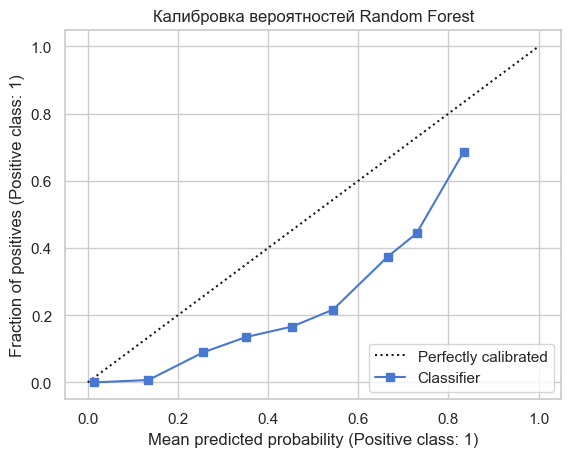

Brier score: 0.09558154716029245


In [32]:
calib_proba = best_forest_fitted.predict_proba(X_calib)[:, 1]

CalibrationDisplay.from_predictions(
    y_calib,
    calib_proba,
    n_bins=10
)

plt.title('Калибровка вероятностей Random Forest')
plt.show()

print('Brier score:', brier_score_loss(y_calib, calib_proba))

In [33]:
calibrated_forest = CalibratedClassifierCV(
    estimator=FrozenEstimator(best_forest_fitted),
    method='isotonic'
)

calibrated_forest.fit(X_calib, y_calib)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat..._state=42))]))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the c

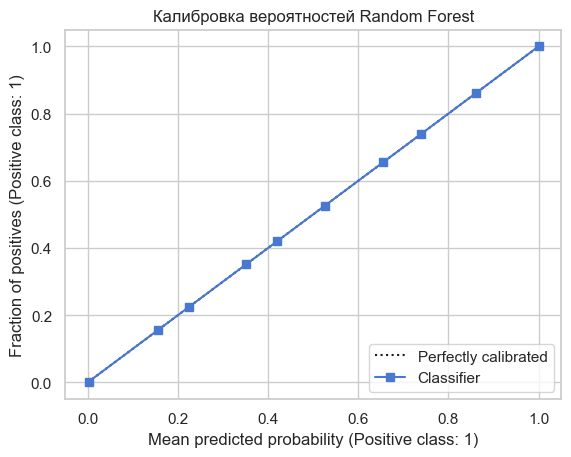

Brier score: 0.06547448563001672


In [34]:
calib_proba = calibrated_forest.predict_proba(X_calib)[:, 1]

CalibrationDisplay.from_predictions(
    y_calib,
    calib_proba,
    n_bins=10
)

plt.title('Калибровка вероятностей Random Forest')
plt.show()

print('Brier score:', brier_score_loss(y_calib, calib_proba))

In [35]:
threshold_results = build_threshold_results(y_calib, calib_proba)

print('Бизнес-ограничения:', business_constraints)
display(
    threshold_results[
        [
            'threshold',
            'approval_rate',
            'default_rate',
            'missed_defaults_rate',
            'accuracy',
            'roc_auc',
            'tn',
            'fp',
            'fn',
            'tp',
            'constraints_met',
        ]
    ]
    .sort_values('threshold')
    .round(4)
)

display(
    threshold_results[
        [
            'threshold',
            'approval_rate',
            'default_rate',
            'missed_defaults_rate',
            'accuracy',
            'roc_auc',
            'tn',
            'fp',
            'fn',
            'tp',
            'constraints_met',
        ]
    ]
    .query('0.10 <= threshold <= 0.13')
    .sort_values('threshold')
    .round(6)
)


Бизнес-ограничения: {'approval_rate_min': 0.65, 'default_rate_max': 0.02, 'missed_defaults_rate_max': 0.04}


,threshold,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc,tn,fp,fn,tp,constraints_met
0,0.0000,0.0000,NaN,0.0000,0.1007,0.9107,0,69741,0,7810,False
1,0.0069,0.6313,0.0000,0.0000,0.7320,0.9107,48960,20781,0,7810,False
2,0.0297,0.6351,0.0000,0.0003,0.7357,0.9107,49249,20492,2,7808,False
3,0.0297,0.6351,0.0001,0.0004,0.7357,0.9107,49249,20492,3,7807,False
4,0.0297,0.6364,0.0001,0.0006,0.7369,0.9107,49346,20395,5,7805,False
...,...,...,...,...,...,...,...,...,...,...,...
74,0.7600,0.9991,0.1001,0.9926,0.8999,0.9107,69729,12,7752,58,False
75,0.7600,0.9991,0.1001,0.9927,0.8999,0.9107,69729,12,7753,57,False
76,0.8000,0.9994,0.1003,0.9950,0.8997,0.9107,69735,6,7771,39,False
77,0.8611,0.9995,0.1003,0.9955,0.8997,0.9107,69736,5,7775,35,False


,threshold,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc,tn,fp,fn,tp,constraints_met
11,0.114894,0.655324,0.002302,0.014981,0.753014,0.910744,50704,19037,117,7693,True
12,0.121102,0.664414,0.003843,0.025352,0.760016,0.910744,51328,18413,198,7612,True
13,0.123457,0.682196,0.006899,0.046735,0.773491,0.910744,52540,17201,365,7445,False
14,0.123457,0.682209,0.006918,0.046863,0.773478,0.910744,52540,17201,366,7444,False
15,0.123457,0.683228,0.007077,0.048015,0.774265,0.910744,52610,17131,375,7435,False


Выбранный вручную порог: 0.1148


,manual_threshold_metrics
threshold,0.1148
approval_rate,0.655324
default_rate,0.002302
missed_defaults_rate,0.014981
accuracy,0.753014
roc_auc,0.910744
tn,50704
fp,19037
fn,117
tp,7693


In [ ]:
best_threshold = 0.1148
best_threshold_metrics = metrics_at_threshold(y_calib, calib_proba, best_threshold)
best_threshold_metrics['constraints_met'] = (
    (best_threshold_metrics['approval_rate'] >= business_constraints['approval_rate_min'])
    and (best_threshold_metrics['default_rate'] <= business_constraints['default_rate_max'])
    and (best_threshold_metrics['missed_defaults_rate'] <= business_constraints['missed_defaults_rate_max'])
)

print('Выбранный порог:', best_threshold)
display(pd.Series(best_threshold_metrics, name='manual_threshold_metrics').to_frame().round(4))

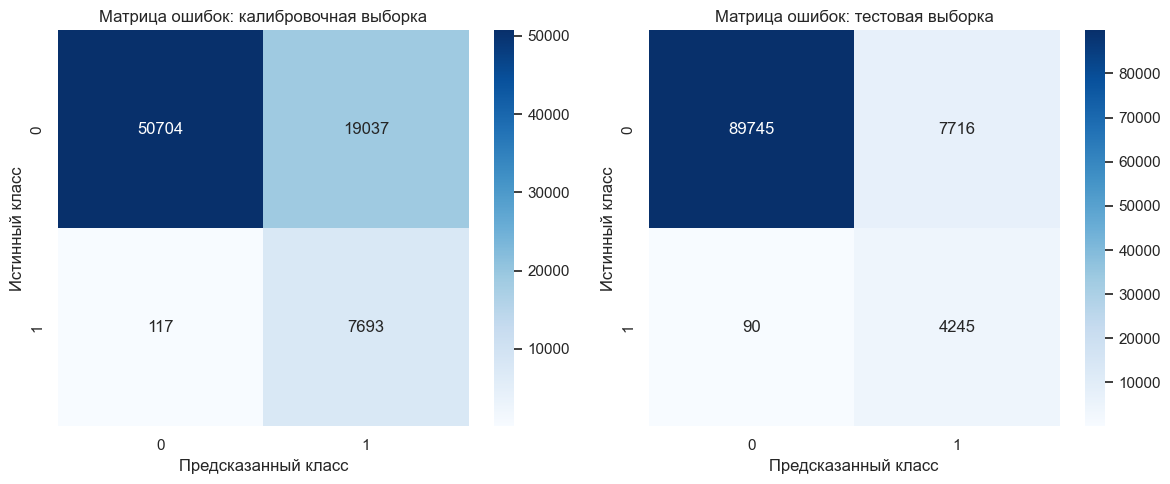

Classification report на тестовой выборке:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     97461
           1       0.35      0.98      0.52      4335

    accuracy                           0.92    101796
   macro avg       0.68      0.95      0.74    101796
weighted avg       0.97      0.92      0.94    101796



,threshold,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc,tn,fp,fn,tp,constraints_met
calibration,0.1148,0.6553,0.0023,0.0150,0.7530,0.9107,50704.0,19037.0,117.0,7693.0,True
test,0.1148,0.8825,0.0010,0.0208,0.9233,0.9662,89745.0,7716.0,90.0,4245.0,True


На calibration и test выполнены все бизнес-ограничения.


In [36]:
test_proba = calibrated_forest.predict_proba(X_test)[:, 1]

calib_pred = (calib_proba >= best_threshold).astype(int)
test_pred = (test_proba >= best_threshold).astype(int)

calib_metrics = metrics_at_threshold(y_calib, calib_proba, best_threshold)
test_metrics = metrics_at_threshold(y_test, test_proba, best_threshold)

assert np.isclose(calib_metrics['threshold'], best_threshold), 'Calibration metrics посчитаны не на выбранном пороге'
assert np.isclose(test_metrics['threshold'], best_threshold), 'Test metrics посчитаны не на выбранном пороге'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    confusion_matrix(y_calib, calib_pred, labels=[0, 1]),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Матрица ошибок: калибровочная выборка')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

sns.heatmap(
    confusion_matrix(y_test, test_pred, labels=[0, 1]),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('Матрица ошибок: тестовая выборка')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

print('Classification report на тестовой выборке:')
print(classification_report(y_test, test_pred))

metrics_compare = pd.DataFrame({
    'calibration': calib_metrics,
    'test': test_metrics,
}).T

metrics_compare['constraints_met'] = (
    (metrics_compare['approval_rate'] >= business_constraints['approval_rate_min'])
    & (metrics_compare['default_rate'] <= business_constraints['default_rate_max'])
    & (metrics_compare['missed_defaults_rate'] <= business_constraints['missed_defaults_rate_max'])
)

display(metrics_compare.round(4))

if metrics_compare.loc['calibration', 'constraints_met'] and metrics_compare.loc['test', 'constraints_met']:
    print('На calibration и test выполнены все бизнес-ограничения.')
elif metrics_compare.loc['calibration', 'constraints_met']:
    print('На calibration ограничения выполнены, но на test выполнены не все бизнес-ограничения.')
else:
    print('На calibration не выполнены все бизнес-ограничения.')


Сначала были выведены бизнес-метрики на всех доступных порогах откалиброванной модели на calibration-выборке. Дополнительно отдельно показан диапазон порогов около рабочей зоны `0.10–0.13`, чтобы выбрать значение без автоматического подбора.

Вручную выбран порог `0.1148`. Он расположен чуть ниже ближайшей ступеньки вероятностей около `0.1149`, поэтому даёт больший запас по `missed defaults rate`, чем порог `0.1149`, но сохраняет `approval rate` выше минимально допустимых 65% на calibration.

Тестовая выборка используется только после фиксации этого порога. Один и тот же порог применяется к calibration и test.


,feature,importance
0,client_age_months,0.0869
1,возраст,0.0789
2,total_spending_roll_12m_std,0.0573
3,total_mcc_spending,0.0537
4,MCC_5411,0.0453
5,total_spending_lag_2m,0.0417
6,MCC_другое,0.0416
7,credit_to_income,0.0414
8,MCC_5722,0.0402
9,total_spending_roll_6m_std,0.0311


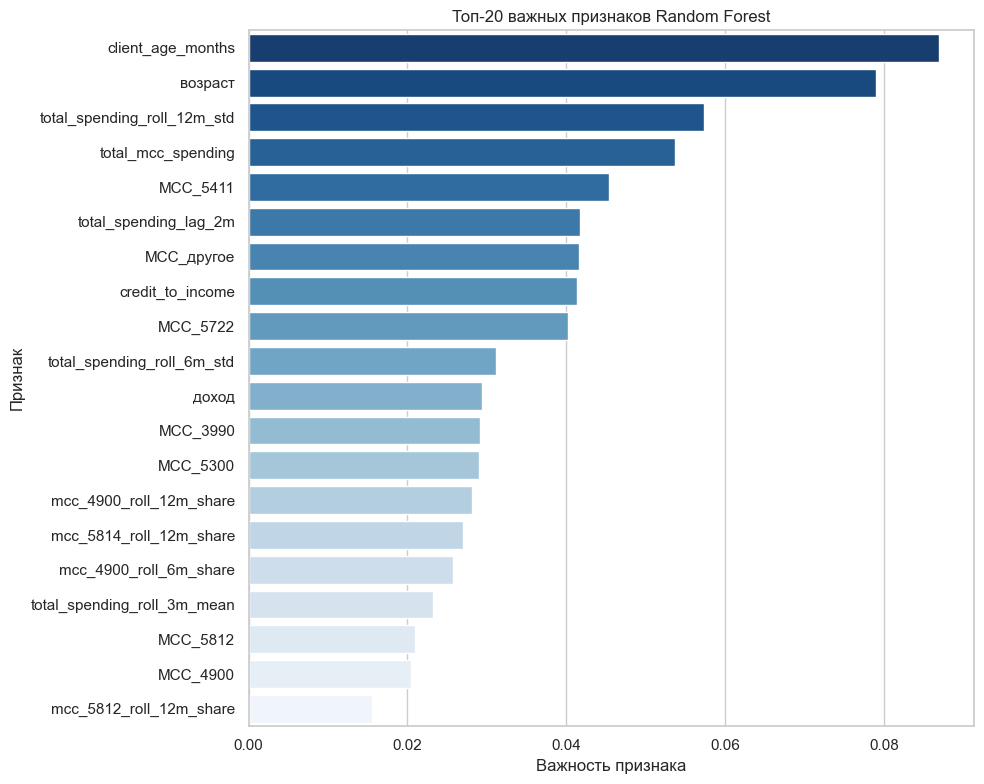

In [37]:
feature_names = best_forest_fitted.named_steps['preprocessor'].get_feature_names_out()
feature_names = [
    name.replace('num__', '').replace('cat__', '')
    for name in feature_names
]

importances = best_forest_fitted.named_steps['model'].feature_importances_

feature_importances_df = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

display(feature_importances_df.head(20).round(4))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importances_df.head(20),
    x='importance',
    y='feature',
    palette='Blues_r'
)
plt.title('Топ-20 важных признаков Random Forest')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


Наиболее сильное влияние на прогноз дефолта оказывает стаж клиента `client_age_months`. Также важными оказались признаки транзакционного поведения: общий объём расходов `total_mcc_spending`, отдельные MCC-категории и лаг расходов `total_spending_lag_2m`.

Среди финансовых характеристик заметный вклад дают `доход`, `credit_to_income`, `возраст` и признаки кредитного рейтинга.

Наименее значимыми для модели оказались `инфляция`, `mcc_5722_share`, `учетная_ставка` и `сумма_кредита`.

Цель проекта заключалась в построении модели поведенческого скоринга, которая оценивает вероятность 90+ просрочки клиента в течение следующих 12 месяцев. Основной акцент был сделан не только на классическом качестве модели, но и на бизнес-метриках: `approval rate`, `default rate` и `missed defaults rate`.

На этапе подготовки были загружены и объединены данные о клиентах, кредитах, транзакциях, ипотеке, кредитном рейтинге, макроэкономических показателях и календаре скоринга. Итоговая таблица строится на базе `cohort_grid`, а целевая переменная формируется для каждой пары `ID + score_date` по первому 90+ дефолтному эпизоду клиента в окне `[score_date, score_date + 365 дней)`. Строки, где первый 90+ дефолт уже произошёл до даты скоринга, удаляются перед присоединением признаков.

Данные разделяются на обучающую, калибровочную и тестовую выборки по времени. Между train и calibration, а также между calibration и test оставлен 12-месячный разрыв, чтобы target-окна предыдущей выборки не пересекались с наблюдениями следующей выборки. Такая схема уменьшает риск временной утечки при оценке качества.

В качестве базовых моделей рассмотрены логистическая регрессия и случайный лес с разными стратегиями балансировки классов. По ROC-AUC лучше выглядят леса, но бизнес-метрики при стандартном пороге показывают, что простое сравнение моделей без калибровки и выбора порога недостаточно для задачи скоринга.

Для итогового решения используется `Random Forest` со стратегией балансировки и подбором гиперпараметров через `Optuna`. После последнего подбора зафиксированы параметры: `n_estimators=1252`, `max_depth=11`, `min_samples_split=30`, `min_samples_leaf=8`, `max_features='sqrt'`, `class_weight='balanced'`.

Для усиления модели добавлены динамические признаки за 3, 6 и 12 месяцев: средние расходы, волатильность расходов, количество месяцев без транзакционной активности, средний кредитный рейтинг, изменение рейтинга и rolling-доли MCC-категорий. Эти признаки помогают модели видеть не только состояние клиента за предыдущий месяц, но и устойчивую динамику поведения. Отдельная проверка rolling-окна подтверждает, что признаки строятся только на текущей и прошлой истории клиента относительно даты скоринга.

Для лучшей модели проводится калибровка вероятностей методом `isotonic`. После калибровки сначала выведены бизнес-метрики на всех доступных порогах calibration-выборки, затем отдельно рассмотрен диапазон порогов около рабочей зоны. Вручную выбран порог `0.1148`: он сохраняет `approval rate` выше 65% и даёт запас по `missed defaults rate`.

Тестовая выборка используется только после фиксации порога на calibration. Один и тот же порог применяется к calibration и test. Итоговые выводы по выполнению бизнес-ограничений делаются по таблице сравнения calibration и test после применения фиксированного порога.

Анализ важности признаков через `feature_importances_` показывает, какие переменные сильнее всего использует Random Forest. Эти важности нужно интерпретировать как вклад признаков в предсказания модели, а не как причинное влияние на дефолт.

Финальный пайплайн включает предобработку числовых и категориальных признаков, обученный `Random Forest`, калибровку вероятностей и выбранный бизнес-порог. Перед практическим использованием такой модели нужно регулярно перепроверять качество на новых временных периодах и пересматривать порог при изменении бизнес-ограничений или структуры портфеля.
